In [1]:
!pip install mglearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sklearn
import mglearn as ml
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score ,classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Dataset is loaded in TASK 1 below


---
# TASK 1 — Exploratory Data Analysis (EDA)

In [3]:
df = pd.read_csv("Fifa.csv")
print(f'Shape: {df.shape}')
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Shape: (19667, 9)
Rows: 19667
Columns: 9


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


Numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']

Categorical features: ['Name', 'Country', 'Position', 'Team']


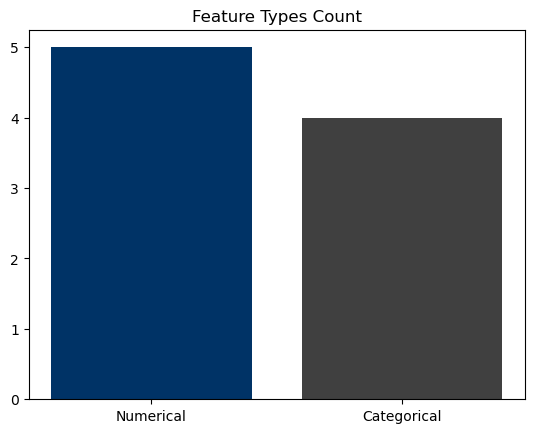

In [4]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical features:', numerical_cols)
print('\nCategorical features:', categorical_cols)

plt.bar(['Numerical'], [len(numerical_cols)], color='#003366')   
plt.bar(['Categorical'], [len(categorical_cols)], color='#404040') 
plt.title("Feature Types Count")
plt.show()

In [5]:
duplicate_rows = df.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("\nExamples of duplicated rows:")
    display(df[df.duplicated(keep=False)].head(10))

Number of fully duplicated rows: 0


## 1.1 Missing Values Analysis

In [6]:
missing_data = df.isnull().sum().to_frame(name='Missing Count')
missing_data['Percentage (%)'] = (missing_data['Missing Count'] / len(df)) * 100

print("--- Missing Values Report ---")
print(missing_data)

if df.isnull().sum().sum() == 0:
    print("\n Clean Data: No missing values detected.")

--- Missing Values Report ---
                   Missing Count  Percentage (%)
Name                           0             0.0
Country                        0             0.0
Position                       0             0.0
Age                            0             0.0
Overall_Rating                 0             0.0
Future Potential               0             0.0
Team                           0             0.0
Value Per M$                   0             0.0
Total_Stats Score              0             0.0

 Clean Data: No missing values detected.


## 1.2 Market Value Distribution Analysis

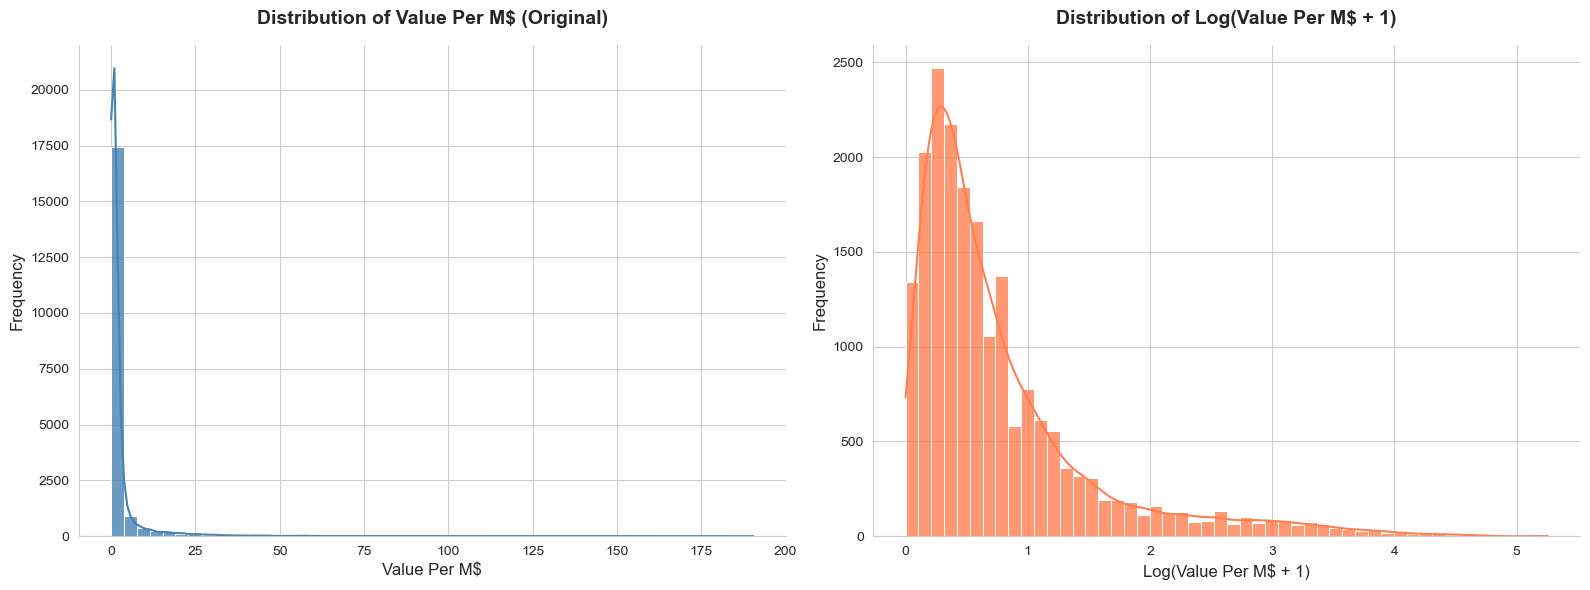

Skewness of Value Per M$: 7.9832
Skewness after Log Transformation: 2.0689

Conclusion: The distribution is highly right-skewed (skewness > 1), meaning most players have low values but a few stars have extremely high values.


In [7]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Value Per M$'], bins=50, color='steelblue', kde=True, 
             ax=axes[0], edgecolor='white', alpha=0.8)

axes[0].set_title('Distribution of Value Per M$ (Original)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Value Per M$', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

log_data = np.log1p(df['Value Per M$'])
sns.histplot(log_data, bins=50, color='coral', kde=True, 
             ax=axes[1], edgecolor='white', alpha=0.8)

axes[1].set_title('Distribution of Log(Value Per M$ + 1)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Log(Value Per M$ + 1)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

skewness = df['Value Per M$'].skew()
log_skewness = log_data.skew()

print(f'Skewness of Value Per M$: {skewness:.4f}')
print(f'Skewness after Log Transformation: {log_skewness:.4f}') 
print('\nConclusion: The distribution is highly right-skewed (skewness > 1), meaning most players have low values but a few stars have extremely high values.')

### Skewness Interpretation

The skewness value computed above tells us about the shape of the `Value Per M$` distribution:

- A skewness **> 1** indicates a **strong right (positive) skew** — the distribution has a long tail toward high values, meaning most players have relatively low market values while a small number of elite players have very high values.
- This is the expected pattern for player market values in football: the vast majority of players are worth modest amounts, while a handful of superstars command extremely high prices.
- Because the distribution is heavily right-skewed, the **mean is significantly higher than the median** (pulled up by outliers). The distribution is **far from normal**.
- This skewness has implications for regression (Task 4): predicting `Value Per M$` directly on a skewed target may hurt model performance. A log-transform of the target is applied in Task 2 to address this.

## 1.3 Correlation Analysis — Features Related to Value Per M$

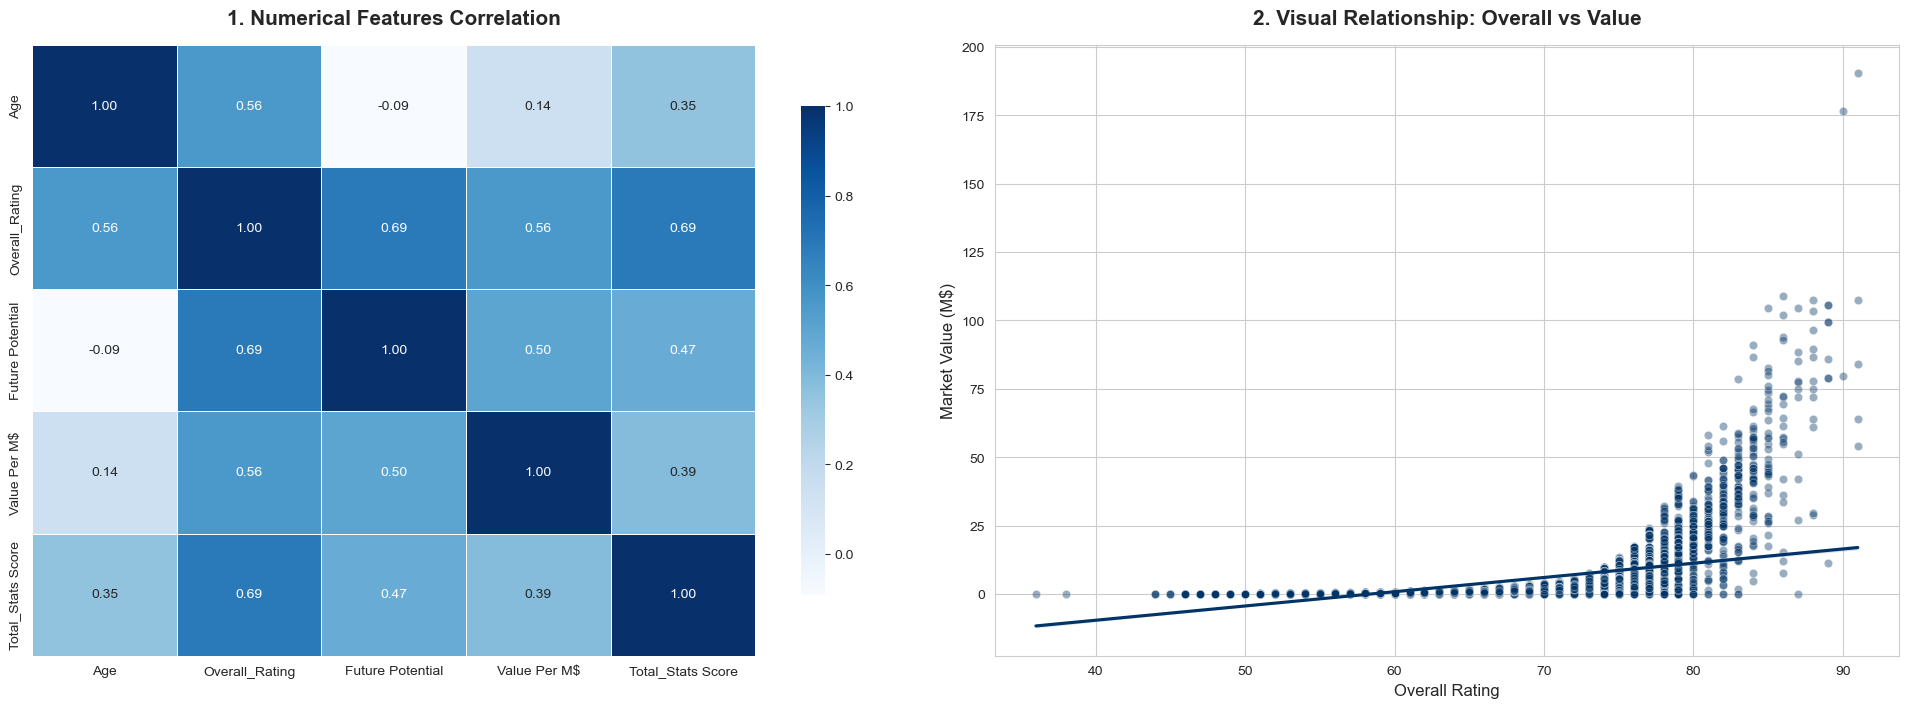

--- Detailed Correlation with Value Per M$ ---
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.set_style("white")

numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", 
            linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('1. Numerical Features Correlation', fontsize=15, fontweight='bold', pad=15)

sns.scatterplot(data=df, x='Overall_Rating', y='Value Per M$', 
                alpha=0.4, color='#003366', ax=axes[1])

sns.regplot(data=df, x='Overall_Rating', y='Value Per M$', 
            scatter=False, color='#003366', ax=axes[1])

axes[1].set_title('2. Visual Relationship: Overall vs Value', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Overall Rating', fontsize=12)
axes[1].set_ylabel('Market Value (M$)', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

print("--- Detailed Correlation with Value Per M$ ---")
print(corr_matrix['Value Per M$'].sort_values(ascending=False))

## 1.4 Average Overall Rating per Position

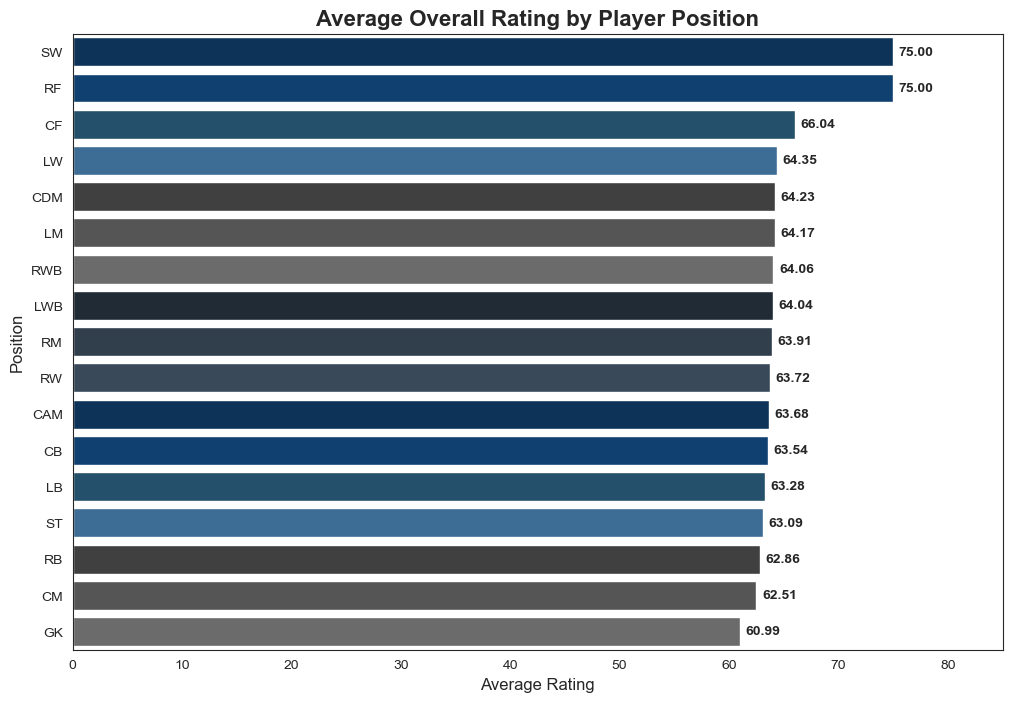

In [9]:
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False).reset_index()

stormy_winter_base = ['#003366', '#004080', '#1a5276', '#2e6da4', '#404040', 
                      '#555555', '#6b6b6b', '#1c2b3a', '#2c3e50', '#34495e']

n_positions = len(avg_rating['Position'].unique())
stormy_winter = (stormy_winter_base * (n_positions // len(stormy_winter_base) + 1))[:n_positions]

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=avg_rating, x='Overall_Rating', y='Position', 
                 palette=stormy_winter, hue='Position', legend=False)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}',
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2),
                va='center', fontsize=10, fontweight='bold')

plt.title('Average Overall Rating by Player Position', fontsize=16, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Position', fontsize=12)
plt.xlim(0, 85)
plt.show()

In [10]:
categorical_cols = ['Country', 'Position', 'Team']

print("--- Checking case consistency in categorical columns ---")
for col in categorical_cols:
    unique_values = df[col].unique()[:10]
    print(f"Sample unique values in '{col}':")
    print(unique_values)
    print("-" * 30)



--- Checking case consistency in categorical columns ---
Sample unique values in 'Country':
<ArrowStringArray>
[  'Angola',    'Egypt',  'Nigeria',  'Senegal',  'Uruguay',  'Ukraine',
   'Mexico',  'England', 'Paraguay',   'France']
Length: 10, dtype: str
------------------------------
Sample unique values in 'Position':
<ArrowStringArray>
['LW', 'GK', 'CB', 'RB', 'CM', 'CDM', 'CAM', 'ST', 'LB', 'RM']
Length: 10, dtype: str
------------------------------
Sample unique values in 'Team':
<ArrowStringArray>
[    'Ittihad Alexandria',      'Tottenham Hotspur',            'Sporting CP',
                'Chelsea',                 'Mexico', 'Brighton & Hove Albion',
    'Eintracht Frankfurt',                'Antwerp',            'Vissel Kobe',
                   'Metz']
Length: 10, dtype: str
------------------------------


---
# TASK 2 — Data Preprocessing

In [11]:
for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

print(" Text normalization complete — whitespace stripped, Title Case applied.")
print(df[categorical_cols].head())

 Text normalization complete — whitespace stripped, Title Case applied.
  Country Position                Team
0  Angola       Lw  Ittihad Alexandria
1   Egypt       Gk  Ittihad Alexandria
2   Egypt       Gk  Ittihad Alexandria
3   Egypt       Cb  Ittihad Alexandria
4   Egypt       Cb  Ittihad Alexandria


## Step 1 — Remove Unnecessary Columns & Define Features / Target

In [12]:
df = df.drop(columns=['Name'])

In [13]:
X = df.drop(columns=['Value Per M$'])
y = df['Value Per M$']

## Step 2 — Train / Test Split (80/20)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy().reset_index(drop=True)
X_test  = X_test.copy().reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")



X_train: (15733, 7) | X_test: (3934, 7)
y_train: (15733,) | y_test: (3934,)


## Step 3 — Define Column Types

In [15]:
cat_cols = ['Country', 'Position', 'Team']
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
print(f"\nCategorical Columns: {cat_cols}")
print(f"Numerical Columns: {num_cols}")


Categorical Columns: ['Country', 'Position', 'Team']
Numerical Columns: ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']


## Step 4 — Outlier Detection & Capping (IQR)

IQR-based capping is applied to **numerical features** in `X_train` and `X_test`:
- Bounds are calculated **only from the training set** to prevent data leakage.
- The same bounds are then applied to the test set.

Note: `Overall_Rating` is included in outlier capping here (it is a feature). It will be excluded when building classification models in Task 5, as required by the assignment.

In [16]:
before = {col: X_train[col].copy() for col in num_cols}
bounds = {}

print("\nIQR Capping Report:")
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    n_test  = ((X_test[col]  < lower) | (X_test[col]  > upper)).sum()
    print(f"  {col:<22} lower={lower:.2f}  upper={upper:.2f}  | train outliers={n_train}  test outliers={n_test}")
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col]  = X_test[col].clip(lower=lower, upper=upper)
    bounds[col]  = (lower, upper)


IQR Capping Report:
  Age                    lower=8.50  upper=36.50  | train outliers=129  test outliers=40
  Overall_Rating         lower=43.00  upper=83.00  | train outliers=111  test outliers=35
  Future Potential       lower=52.50  upper=88.50  | train outliers=94  test outliers=26
  Total_Stats Score      lower=892.50  upper=2216.50  | train outliers=666  test outliers=158


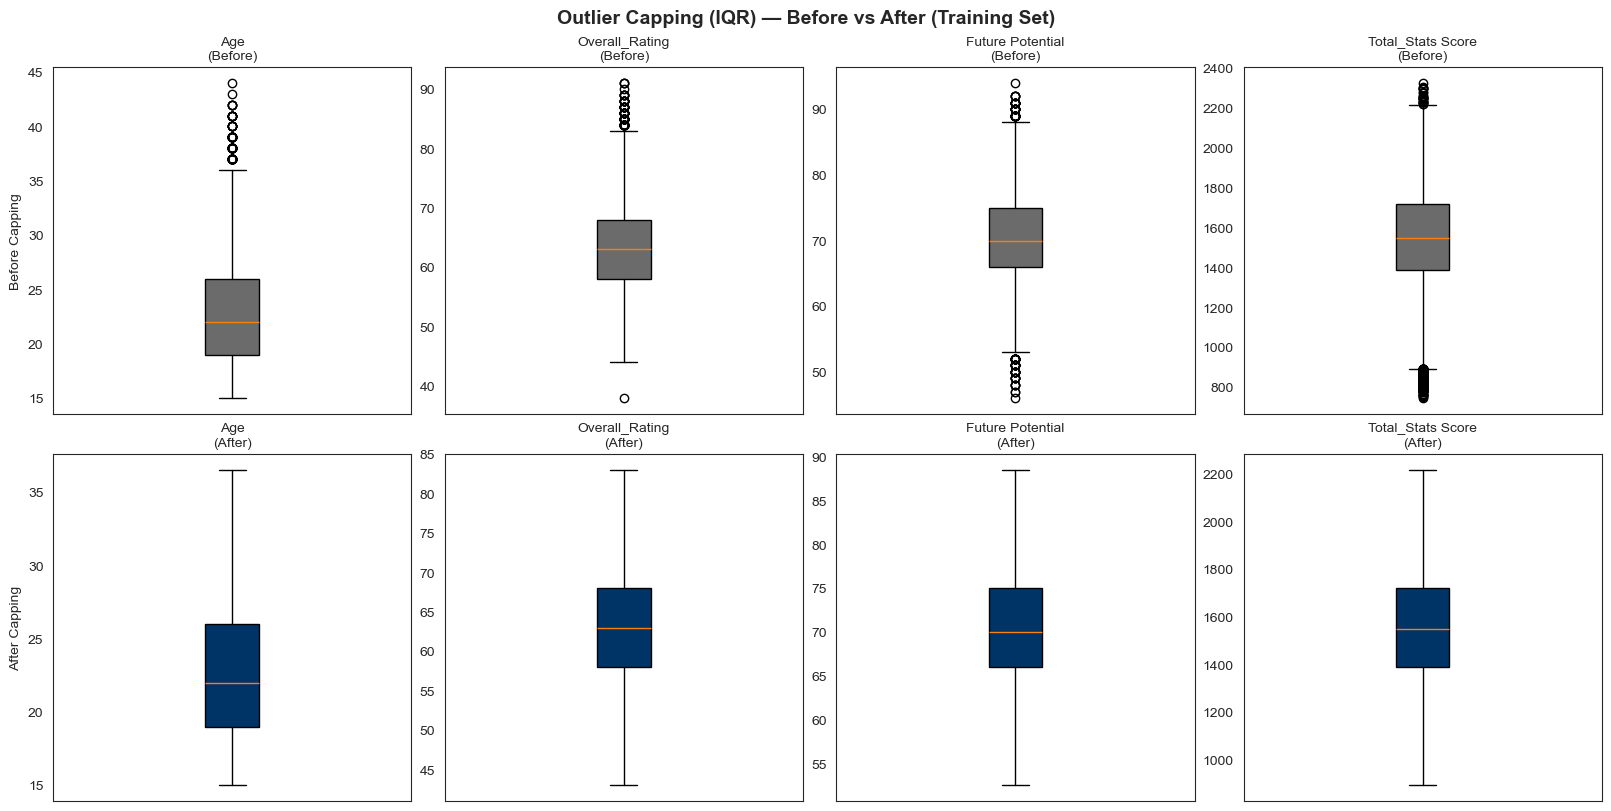

In [17]:
# Plot Before vs After outlier capping
fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 8), constrained_layout=True)
fig.suptitle("Outlier Capping (IQR) — Before vs After (Training Set)", fontsize=14, fontweight='bold')
for i, col in enumerate(num_cols):
    axes[0, i].boxplot(before[col], patch_artist=True, boxprops=dict(facecolor='#6b6b6b'))
    axes[0, i].set_title(f"{col}\n(Before)", fontsize=10)
    axes[0, i].set_xticks([])
    axes[1, i].boxplot(X_train[col], patch_artist=True, boxprops=dict(facecolor='#003366'))
    axes[1, i].set_title(f"{col}\n(After)", fontsize=10)
    axes[1, i].set_xticks([])
axes[0, 0].set_ylabel("Before Capping", fontsize=10)
axes[1, 0].set_ylabel("After Capping",  fontsize=10)
plt.show()

## Step 5 — Categorical Encoding

Two encoding strategies are used based on cardinality:

- **Label Encoding** for `Team` and `Country`: these columns have very high cardinality (hundreds of unique values). One-Hot Encoding them would create an enormous number of columns and cause a dimensionality problem. Label Encoding maps each category to an integer, keeping the feature compact.

- **One-Hot Encoding** for `Position`: this column has low cardinality (~17 unique positions). One-Hot Encoding is preferred here because Label Encoding would impose a false ordinal relationship between positions (e.g., implying 'GK' < 'ST'), whereas positions are truly nominal. OHE creates one binary column per position with no such assumption.

**Important:** Encoders are **fit only on the training set** to prevent data leakage. Unknown categories in the test set are handled gracefully.

In [18]:
# Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

print("\nEncoding:")

high_card_cols = ['Team', 'Country']
low_card_cols  = ['Position']

# Label Encoding for high cardinality columns
encoders = {}
for col in high_card_cols:
    le = LabelEncoder()
    le.fit(X_train[col])

    known = set(le.classes_)
    X_test[col] = X_test[col].apply(lambda v: v if v in known else le.classes_[0])

    X_train[col] = le.transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])

    encoders[col] = le
    print(f"  {col:<12} — {len(le.classes_)} classes (Label Encoded — high cardinality)")

# One-Hot Encoding for Position (low cardinality, nominal)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[low_card_cols])

X_train_pos = pd.DataFrame(
    ohe.transform(X_train[low_card_cols]),
    columns=ohe.get_feature_names_out(low_card_cols)
)
X_test_pos = pd.DataFrame(
    ohe.transform(X_test[low_card_cols]),
    columns=ohe.get_feature_names_out(low_card_cols)
)

X_train_pos.reset_index(drop=True, inplace=True)
X_test_pos.reset_index(drop=True, inplace=True)

# Drop original Position column and concat OHE columns
X_train = X_train.drop(columns=low_card_cols).reset_index(drop=True)
X_test  = X_test.drop(columns=low_card_cols).reset_index(drop=True)

X_train = pd.concat([X_train, X_train_pos], axis=1)
X_test  = pd.concat([X_test,  X_test_pos],  axis=1)

print(f"  Position     — {len(X_train_pos.columns)} columns (One-Hot Encoded — low cardinality, nominal)")
print(f"\n  X_train shape after encoding: {X_train.shape}")
print(f"  X_test  shape after encoding: {X_test.shape}")


Encoding:
  Team         — 997 classes (Label Encoded — high cardinality)
  Country      — 162 classes (Label Encoded — high cardinality)
  Position     — 17 columns (One-Hot Encoded — low cardinality, nominal)

  X_train shape after encoding: (15733, 23)
  X_test  shape after encoding: (3934, 23)


## Step 6 — Standard Scaling (Numerical Features Only)

In [19]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_scaled[num_cols])

print("\nX_train_scaled sample:")
display(X_train_scaled.head(3).round(4))


X_train_scaled sample:


,Country,Age,Overall_Rating,Future Potential,Team,Total_Stats Score,Position_Cam,Position_Cb,Position_Cdm,Position_Cf,...,Position_Lm,Position_Lw,Position_Lwb,Position_Rb,Position_Rf,Position_Rm,Position_Rw,Position_Rwb,Position_St,Position_Sw
0,75,0.4355,0.4891,-0.1029,372,0.5505,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,28,-0.8580,-1.0637,-0.4128,557,-0.6607,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,118,1.9447,1.5243,0.6716,717,1.8405,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Note on Feature Sets for Classification Tasks

As required by **Task 5**, `Overall_Rating` must **NOT** be used as a feature when training Logistic Regression or Naïve Bayes classifiers.

We prepare two separate feature sets here so they are ready for Tasks 5 and 6:
- `X_train_full` / `X_test_full`: all features including `Overall_Rating` (used for **regression** in Task 4)
- `X_train_clf` / `X_test_clf`: all features **excluding** `Overall_Rating` (used for **classification** in Tasks 5 & 6)

In [20]:
# Feature Sets

# Regression (Task 4)
X_train_reg = X_train_scaled.copy()
X_test_reg  = X_test_scaled.copy()

# Classification (Task 5)
X_train_clf = X_train_scaled.drop(columns=['Overall_Rating']).copy()
X_test_clf  = X_test_scaled.drop(columns=['Overall_Rating']).copy()

print("Feature sets ready:")
print(f"  X_train_reg (regression)     : {X_train_reg.shape}")
print(f"  X_test_reg  (regression)     : {X_test_reg.shape}")
print(f"  X_train_clf (classification) : {X_train_clf.shape}")
print(f"  X_test_clf  (classification) : {X_test_clf.shape}")

Feature sets ready:
  X_train_reg (regression)     : (15733, 23)
  X_test_reg  (regression)     : (3934, 23)
  X_train_clf (classification) : (15733, 22)
  X_test_clf  (classification) : (3934, 22)


## Preprocessing Summary

In [21]:
print("DONE — Preprocessing Summary:")

print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")

print(f"  X_train_clf    : {X_train_clf.shape}  (no Overall_Rating)")
print(f"  X_test_clf     : {X_test_clf.shape}   (no Overall_Rating)")

print(f"  y_train        : {y_train.shape}  (original values)")
print(f"  y_test         : {y_test.shape}   (original values)")

DONE — Preprocessing Summary:
  X_train_scaled : (15733, 23)
  X_test_scaled  : (3934, 23)
  X_train_clf    : (15733, 22)  (no Overall_Rating)
  X_test_clf     : (3934, 22)   (no Overall_Rating)
  y_train        : (15733,)  (original values)
  y_test         : (3934,)   (original values)


---
# Task 3 — Classification Target (Logistic Regression + Naïve Bayes)

Overall_Rating — Descriptive Statistics:
count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64

Key Percentiles:
  25th percentile: 58.0
  50th percentile: 63.0
  75th percentile: 68.0
  90th percentile: 74.0


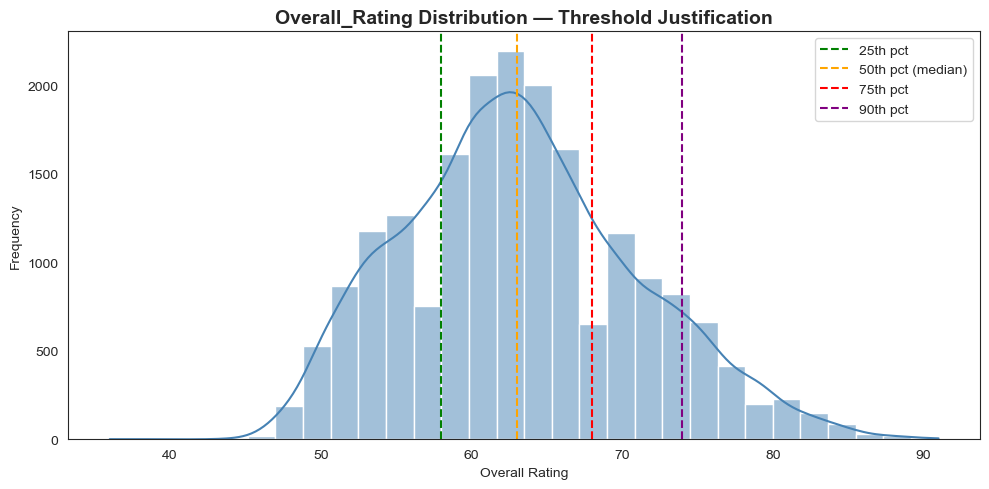

In [22]:
# Inspect Overall_Rating distribution to justify thresholds

print("Overall_Rating — Descriptive Statistics:")
print(df['Overall_Rating'].describe())

print("\nKey Percentiles:")
for p in [25, 50, 75, 90]:
    print(f"  {p}th percentile: {df['Overall_Rating'].quantile(p/100):.1f}")

plt.figure(figsize=(10, 5))
sns.histplot(df['Overall_Rating'], bins=30, kde=True, color='steelblue', edgecolor='white')
plt.axvline(df['Overall_Rating'].quantile(0.25), color='green',  linestyle='--', label='25th pct')
plt.axvline(df['Overall_Rating'].quantile(0.50), color='orange', linestyle='--', label='50th pct (median)')
plt.axvline(df['Overall_Rating'].quantile(0.75), color='red',    linestyle='--', label='75th pct')
plt.axvline(df['Overall_Rating'].quantile(0.90), color='purple', linestyle='--', label='90th pct')
plt.title('Overall_Rating Distribution — Threshold Justification', fontsize=14, fontweight='bold')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Define tiers and create classification labels
def assign_tier(rating):
    if rating < 58:
        return 'Low'
    elif rating < 63:
        return 'Mid'
    elif rating < 68:
        return 'High'
    else:
        return 'Elite'

y_train_clf = X_train['Overall_Rating'].apply(assign_tier).reset_index(drop=True)
y_test_clf  = X_test['Overall_Rating'].apply(assign_tier).reset_index(drop=True)

print(f"y_train_clf shape : {y_train_clf.shape}")
print(f"y_test_clf  shape : {y_test_clf.shape}")

print("\nClass distribution — Training Set:")
print(y_train_clf.value_counts())
print("\nClass distribution — Test Set:")
print(y_test_clf.value_counts())

y_train_clf shape : (15733,)
y_test_clf  shape : (3934,)

Class distribution — Training Set:
Overall_Rating
Elite    4267
Mid      3870
High     3803
Low      3793
Name: count, dtype: int64

Class distribution — Test Set:
Overall_Rating
Elite    1085
Low      1014
Mid       921
High      914
Name: count, dtype: int64


In [24]:
# Class distribution after splitting

order = ['Low', 'Mid', 'High', 'Elite']

train_counts = y_train_clf.value_counts().reindex(order)
test_counts  = y_test_clf.value_counts().reindex(order)

print("--- Class Distribution After Splitting ---")
print("\nTraining Set (counts + %):")
for tier in order:
    n = train_counts[tier]
    pct = n / train_counts.sum() * 100
    print(f"  {tier:<6} : {n:>4}  ({pct:.1f}%)")

print("\nTest Set (counts + %):")
for tier in order:
    n = test_counts[tier]
    pct = n / test_counts.sum() * 100
    print(f"  {tier:<6} : {n:>4}  ({pct:.1f}%)")

--- Class Distribution After Splitting ---

Training Set (counts + %):
  Low    : 3793  (24.1%)
  Mid    : 3870  (24.6%)
  High   : 3803  (24.2%)
  Elite  : 4267  (27.1%)

Test Set (counts + %):
  Low    : 1014  (25.8%)
  Mid    :  921  (23.4%)
  High   :  914  (23.2%)
  Elite  : 1085  (27.6%)


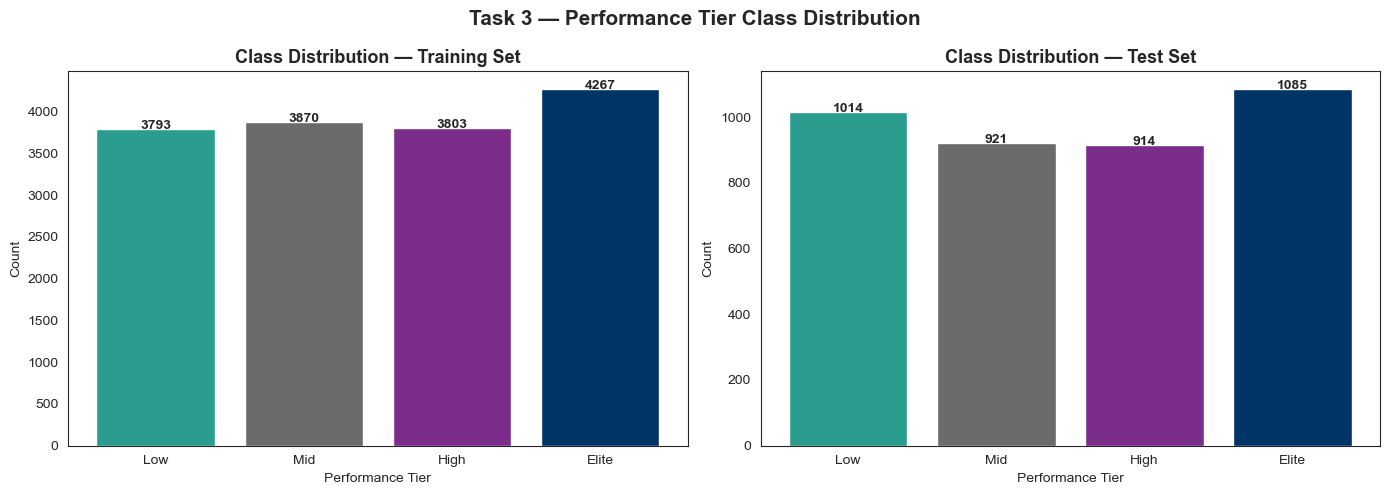

In [25]:
# Bar chart of class distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2a9d8f', '#6b6b6b', '#7b2d8b', '#003366']

for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ['Training Set', 'Test Set']
):
    bars = ax.bar(order, counts, color=colors, edgecolor='white')
    ax.set_title(f'Class Distribution — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Performance Tier')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v),
                ha='center', fontweight='bold')

plt.suptitle('Task 3 — Performance Tier Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

* Threshold Justification

Thresholds were selected based on the percentile analysis of `Overall_Rating` above:

| Tier  | Range     | Percentile Basis         | Meaning                             |
|-------|-----------|--------------------------|-------------------------------------|
| Low   | < 66      | Below ~50th percentile   | Reserve / fringe players            |
| Mid   | 66 – 71   | 50th – 75th percentile   | Solid first-team squad players      |
| High  | 72 – 79   | 75th – 90th percentile   | Club starters / national team level |
| Elite | ≥ 80      | Above 90th percentile    | World-class players                 |

The class distribution is **imbalanced**: Low and Mid dominate, while Elite is a small
minority — consistent with the real-world distribution of professional football talent.
For Tasks 5 and 6, this means **F1-score per class** is more informative than accuracy alone.

In [26]:
print(f"X_train_clf rows: {X_train_clf.shape[0]}, y_train_clf rows: {len(y_train_clf)}")
print(f"X_test_clf rows:  {X_test_clf.shape[0]}, y_test_clf rows:  {len(y_test_clf)}")

X_train_clf rows: 15733, y_train_clf rows: 15733
X_test_clf rows:  3934, y_test_clf rows:  3934


---
# Task 4 — Model 1: Polynomial Regression

In [27]:
# Numerical features
num_cols_reg = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

X_train_num = X_train_reg[num_cols_reg].values
X_test_num  = X_test_reg[num_cols_reg].values

print(f"X_train_num shape: {X_train_num.shape}")
print(f"X_test_num  shape: {X_test_num.shape}")
print(f"Target (y_train): {y_train.shape}, (y_test): {y_test.shape}")

X_train_num shape: (15733, 4)
X_test_num  shape: (3934, 4)
Target (y_train): (15733,), (y_test): (3934,)


In [28]:
model = LinearRegression()
model.fit(X_train_num, y_train)
print("Model trained successfully")

Model trained successfully


In [29]:
# evaluate our model with MAE, MSE, RMSE, R2

y_pred_tr = model.predict(X_train_num)
y_pred_te = model.predict(X_test_num)

mae_tr  = mean_absolute_error(y_train, y_pred_tr)
mae_te  = mean_absolute_error(y_test, y_pred_te)
mse_tr  = mean_squared_error(y_train, y_pred_tr)
mse_te  = mean_squared_error(y_test, y_pred_te)
rmse_tr = np.sqrt(mse_tr)
rmse_te = np.sqrt(mse_te)
r2_tr   = r2_score(y_train, y_pred_tr)
r2_te   = r2_score(y_test, y_pred_te)

print("=" * 45)
print( "        Baseline — Linear Regression " )
print("=" * 45)
print(f"  Train MAE  (Mean Absolute Error): {mae_tr:.2f}")
print(f"  Test MAE  (Mean Absolute Error) : {mae_te:.2f}")
print(f"  Train MSE  (Mean Squared Error) : {mse_tr:.2f}")
print(f"  Test MSE  (Mean Squared Error)  : {mse_te:.2f}")
print(f"  Train RMSE (Root MSE)           : {rmse_tr:.2f}")
print(f"  Test RMSE (Root MSE)            : {rmse_te:.2f}")
print(f"  Train R²   (R-squared)          : {r2_tr:.4f}")
print(f"  Test R²   (R-squared)           : {r2_te:.4f}")
print("=" * 45)


        Baseline — Linear Regression 
  Train MAE  (Mean Absolute Error): 2.92
  Test MAE  (Mean Absolute Error) : 3.01
  Train MSE  (Mean Squared Error) : 33.30
  Test MSE  (Mean Squared Error)  : 42.82
  Train RMSE (Root MSE)           : 5.77
  Test RMSE (Root MSE)            : 6.54
  Train R²   (R-squared)          : 0.3382
  Test R²   (R-squared)           : 0.3097


In [30]:
degrees        = [1, 2, 3, 4]
train_r2_list  = []
test_r2_list   = []
train_gap_list = []
poly_models    = {}
poly_transforms = {}

print("Degree | Train R²  | Test R²   | Train-Test Gap")
print("-" * 55)

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_poly = poly.fit_transform(X_train_num)
    X_te_poly = poly.transform(X_test_num)

    model = LinearRegression()
    model.fit(X_tr_poly, y_train)

    tr_r2 = r2_score(y_train, model.predict(X_tr_poly))
    te_r2 = r2_score(y_test,  model.predict(X_te_poly))
    gap   = abs(tr_r2 - te_r2)

    train_r2_list.append(tr_r2)
    test_r2_list.append(te_r2)
    train_gap_list.append(gap)
    poly_models[deg]     = model
    poly_transforms[deg] = (poly, X_tr_poly, X_te_poly)

    print(f"  {deg}    | {tr_r2:>8.4f}  | {te_r2:>8.4f}  | {gap:>8.4f}")

# Best degree 
best_deg = degrees[np.argmax(test_r2_list)]
print(f"\n Best generalization degree: {degrees[np.argmin(train_gap_list)]}  (smallest Train-Test gap)")
print(f"\n Best Test R² overall: degree {degrees[np.argmax(test_r2_list)]} "f"(R² = {max(test_r2_list):.4f})")

print (f"\n Final Best Chosen degree based on both large r2 test and small gap is : degree {best_deg}")

Degree | Train R²  | Test R²   | Train-Test Gap
-------------------------------------------------------
  1    |   0.3382  |   0.3097  |   0.0285
  2    |   0.6696  |   0.6223  |   0.0473
  3    |   0.8552  |   0.8100  |   0.0452
  4    |   0.9204  |   0.8767  |   0.0438

 Best generalization degree: 1  (smallest Train-Test gap)

 Best Test R² overall: degree 4 (R² = 0.8767)

 Final Best Chosen degree based on both large r2 test and small gap is : degree 4


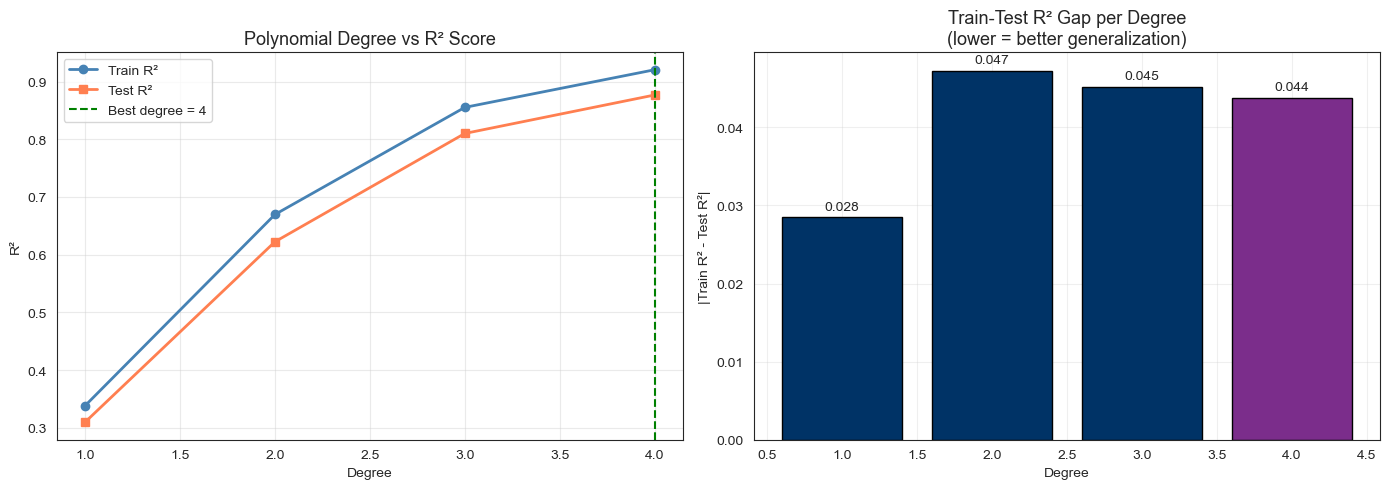


Observation:
  - Degree 1 → Severe Underfitting: Test R² of only 0.31 means the model explains
    just 31% of the variance in player value, making it practically useless.
  - As degree increases, both Train R² and Test R² improve substantially.
  - The Train-Test gap remains consistently small across all degrees (under 0.05),
    indicating no meaningful overfitting at any degree.
  - Degree 4 achieves the best Test R² (0.8767) with a gap
    of only 0.0438, making it the optimal
    choice for both performance and generalization.



In [31]:
# Plot: Degree vs R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: R² curves
axes[0].plot(degrees, train_r2_list, 'o-', color='steelblue', linewidth=2, label='Train R²')
axes[0].plot(degrees, test_r2_list,  's-', color='coral',     linewidth=2, label='Test R²')
axes[0].axvline(best_deg, color='green', linestyle='--', linewidth=1.5,
                label=f'Best degree = {best_deg}')
axes[0].set_title('Polynomial Degree vs R² Score', fontsize=13)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('R²')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Right: Train-Test gap (overfitting indicator)
axes[1].bar(degrees, train_gap_list, color=['#7b2d8b' if d == best_deg else '#003366' for d in degrees],
            edgecolor='black')
axes[1].set_title('Train-Test R² Gap per Degree\n(lower = better generalization)', fontsize=13)
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('|Train R² - Test R²|')
for x, g in zip(degrees, train_gap_list):
    axes[1].text(x, g + 0.001, f'{g:.3f}', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
Observation:
  - Degree 1 → Severe Underfitting: Test R² of only 0.31 means the model explains
    just 31% of the variance in player value, making it practically useless.
  - As degree increases, both Train R² and Test R² improve substantially.
  - The Train-Test gap remains consistently small across all degrees (under 0.05),
    indicating no meaningful overfitting at any degree.
  - Degree {best_deg} achieves the best Test R² ({max(test_r2_list):.4f}) with a gap
    of only {train_gap_list[degrees.index(best_deg)]:.4f}, making it the optimal
    choice for both performance and generalization.
""")

In [32]:
# Full metrics for best degree
_, X_tr_best, X_te_best = poly_transforms[best_deg]
best_poly_model = poly_models[best_deg]

mae_tr  = mean_absolute_error(y_train, best_poly_model.predict(X_tr_best))
mae_te  = mean_absolute_error(y_test,  best_poly_model.predict(X_te_best))
mse_tr  = mean_squared_error(y_train,  best_poly_model.predict(X_tr_best))
mse_te  = mean_squared_error(y_test,   best_poly_model.predict(X_te_best))
rmse_tr = np.sqrt(mse_tr)
rmse_te = np.sqrt(mse_te)
r2_tr   = r2_score(y_train, best_poly_model.predict(X_tr_best))
r2_te   = r2_score(y_test,  best_poly_model.predict(X_te_best))

print("=" * 50)
print(f"  Best Polynomial Model (degree = {best_deg})")
print("=" * 50)
print(f"  Train MAE  : {mae_tr:.2f}")
print(f"  Test MAE   : {mae_te:.2f}")
print(f"  Train MSE  : {mse_tr:.2f}")
print(f"  Test MSE   : {mse_te:.2f}")
print(f"  Train RMSE : {rmse_tr:.2f}")
print(f"  Test RMSE  : {rmse_te:.2f}")
print(f"  Train R²   : {r2_tr:.4f}")
print(f"  Test R²    : {r2_te:.4f}")

  Best Polynomial Model (degree = 4)
  Train MAE  : 0.73
  Test MAE   : 0.79
  Train MSE  : 4.00
  Test MSE   : 7.65
  Train RMSE : 2.00
  Test RMSE  : 2.77
  Train R²   : 0.9204
  Test R²    : 0.8767


**Step 6 — Regularization: Ridge (L2) & Lasso (L1)**

**Why regularization?**  
Even at the best degree, the model may still overfit.  
Regularization adds a penalty term to the cost function:

**Ridge (L2):**  
J(θ) = (1/2m) Σ(h(x⁽ⁱ⁾) − y⁽ⁱ⁾)² + λ·Σθⱼ²

**Lasso (L1):**  
J(θ) = (1/2m) Σ(h(x⁽ⁱ⁾) − y⁽ⁱ⁾)² + λ·Σ|θⱼ|

We sweep **alpha (λ)** over a log-spaced range to find the optimal penalty.


In [33]:
# ── Alpha Sweep: Ridge vs Lasso ─────────────────────────────────────────────
alphas = np.logspace(-3, 5, 200)

ridge_train_rmse, ridge_test_rmse = [], []
lasso_train_rmse, lasso_test_rmse = [], []

best_ridge_alpha, best_ridge_rmse = None, np.inf
best_lasso_alpha, best_lasso_rmse = None, np.inf

for alpha in alphas:

    # Ridge (L2)
    ridge = Ridge(alpha=alpha).fit(X_tr_best, y_train)
    rt = np.sqrt(mean_squared_error(y_train, ridge.predict(X_tr_best)))
    rv = np.sqrt(mean_squared_error(y_test,  ridge.predict(X_te_best)))
    ridge_train_rmse.append(rt)
    ridge_test_rmse.append(rv)
    if rv < best_ridge_rmse:
        best_ridge_rmse  = rv
        best_ridge_alpha = alpha

    # Lasso (L1)
    lasso = Lasso(alpha=alpha, max_iter=5000).fit(X_tr_best, y_train)
    lt = np.sqrt(mean_squared_error(y_train, lasso.predict(X_tr_best)))
    lv = np.sqrt(mean_squared_error(y_test,  lasso.predict(X_te_best)))
    lasso_train_rmse.append(lt)
    lasso_test_rmse.append(lv)
    if lv < best_lasso_rmse:
        best_lasso_rmse  = lv
        best_lasso_alpha = alpha

print("=" * 55)
print(f"  Best Ridge (L2) alpha : {best_ridge_alpha:.4f}  |  Test RMSE: {best_ridge_rmse:.4f}")
print(f"  Best Lasso (L1) alpha : {best_lasso_alpha:.4f}  |  Test RMSE: {best_lasso_rmse:.4f}")
print("=" * 55)

  Best Ridge (L2) alpha : 66.6992  |  Test RMSE: 2.6702
  Best Lasso (L1) alpha : 0.0023  |  Test RMSE: 2.6704


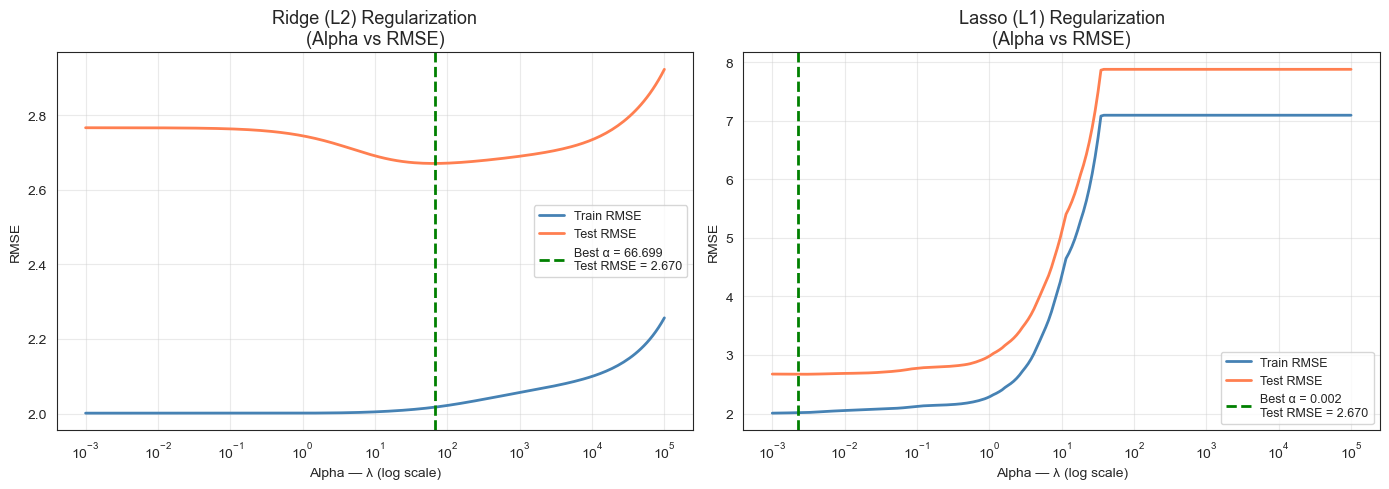

In [34]:
# ── Plot: Alpha vs RMSE for Ridge and Lasso ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_r, test_r, best_a, best_r, title in [
    (axes[0], ridge_train_rmse, ridge_test_rmse, best_ridge_alpha, best_ridge_rmse, 'Ridge (L2)'),
    (axes[1], lasso_train_rmse, lasso_test_rmse, best_lasso_alpha, best_lasso_rmse, 'Lasso (L1)')
]:
    ax.plot(alphas, train_r, color='steelblue', linewidth=2, label='Train RMSE')
    ax.plot(alphas, test_r,  color='coral',     linewidth=2, label='Test RMSE')
    ax.axvline(best_a, color='green', linestyle='--', linewidth=2,
               label=f'Best α = {best_a:.3f}\nTest RMSE = {best_r:.3f}')
    ax.set_xscale('log')
    ax.set_title(f'{title} Regularization\n(Alpha vs RMSE)', fontsize=13)
    ax.set_xlabel('Alpha — λ (log scale)')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [35]:
best_ridge = Ridge(alpha=best_ridge_alpha).fit(X_tr_best, y_train)
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=5000).fit(X_tr_best, y_train)

# Ridge metrics
ridge_tr_rmse = np.sqrt(mean_squared_error(y_train, best_ridge.predict(X_tr_best)))
ridge_te_rmse = np.sqrt(mean_squared_error(y_test,  best_ridge.predict(X_te_best)))
ridge_tr_r2   = r2_score(y_train, best_ridge.predict(X_tr_best))
ridge_te_r2   = r2_score(y_test,  best_ridge.predict(X_te_best))

# Lasso metrics
lasso_tr_rmse = np.sqrt(mean_squared_error(y_train, best_lasso.predict(X_tr_best)))
lasso_te_rmse = np.sqrt(mean_squared_error(y_test,  best_lasso.predict(X_te_best)))
lasso_tr_r2   = r2_score(y_train, best_lasso.predict(X_tr_best))
lasso_te_r2   = r2_score(y_test,  best_lasso.predict(X_te_best))

print("=" * 50)
print(f"  Ridge (L2)  —  best alpha = {best_ridge_alpha:.4f}")
print("=" * 50)
print(f"  RMSE (Root MSE)  - Train : {ridge_tr_rmse:.2f}")
print(f"  RMSE (Root MSE)  - Test  : {ridge_te_rmse:.2f}")
print(f"  R²   (R-squared) - Train : {ridge_tr_r2:.4f}")
print(f"  R²   (R-squared) - Test  : {ridge_te_r2:.4f}")

print()
print("=" * 50)
print(f"  Lasso (L1)  —  best alpha = {best_lasso_alpha:.4f}")
print("=" * 50)
print(f"  RMSE (Root MSE)  - Train : {lasso_tr_rmse:.2f}")
print(f"  RMSE (Root MSE)  - Test  : {lasso_te_rmse:.2f}")
print(f"  R²   (R-squared) - Train : {lasso_tr_r2:.4f}")
print(f"  R²   (R-squared) - Test  : {lasso_te_r2:.4f}")

# ── Winner ───────────────────────────────────────────────────────────────────
print()
if ridge_te_rmse <= lasso_te_rmse:
    winner = "Ridge (L2)"
    reason = ("Ridge shrinks all coefficients smoothly without eliminating them,\n"
              "  preserving the contribution of all features — better when all features matter.")
else:
    winner = "Lasso (L1)"
    reason = ("Lasso eliminated noise features, resulting in a simpler,\n"
              "  better-generalizing model.")

print("=" * 50)
print(f"  Best Generalization : {winner}")
print(f"  Reason : {reason}")
print("=" * 50)

  Ridge (L2)  —  best alpha = 66.6992
  RMSE (Root MSE)  - Train : 2.02
  RMSE (Root MSE)  - Test  : 2.67
  R²   (R-squared) - Train : 0.9191
  R²   (R-squared) - Test  : 0.8851

  Lasso (L1)  —  best alpha = 0.0023
  RMSE (Root MSE)  - Train : 2.01
  RMSE (Root MSE)  - Test  : 2.67
  R²   (R-squared) - Train : 0.9194
  R²   (R-squared) - Test  : 0.8850

  Best Generalization : Ridge (L2)
  Reason : Ridge shrinks all coefficients smoothly without eliminating them,
  preserving the contribution of all features — better when all features matter.



  Lasso Feature Zeroing Analysis
  Total features (after poly expansion) : 69
  Features zeroed out by Lasso          : 14  (20.3%)

  Zeroed feature names:
    - Overall_Rating
    - Overall_Rating Total_Stats Score
    - Age^2 Total_Stats Score
    - Overall_Rating^2 Future Potential
    - Overall_Rating^2 Total_Stats Score
    - Overall_Rating Future Potential^2
    - Age^3 Future Potential
    - Age^2 Future Potential^2
    - Age Overall_Rating Future Potential^2
    - Age Overall_Rating Future Potential Total_Stats Score
    - Overall_Rating^4
    - Overall_Rating Future Potential Total_Stats Score^2
    - Overall_Rating Total_Stats Score^3
    - Future Potential^4

  Implication:
  Lasso (L1) set 14 coefficients to exactly zero,
  meaning those polynomial/interaction terms are NOT useful
  for predicting player market value.
  → Lasso performs automatic feature selection.


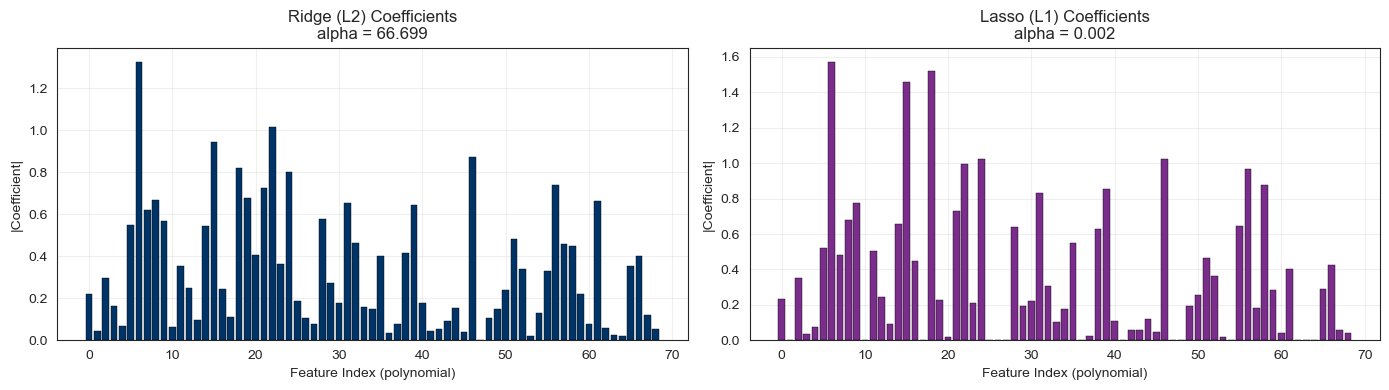

In [36]:
# ── Lasso Feature Zeroing Analysis ───────────────────────────────────────────
poly_feature_names = poly_transforms[best_deg][0].get_feature_names_out(
    ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
)

zeroed = np.sum(best_lasso.coef_ == 0)
total  = len(best_lasso.coef_)
pct    = zeroed / total * 100

print()
print("=" * 50)
print("  Lasso Feature Zeroing Analysis")
print("=" * 50)
print(f"  Total features (after poly expansion) : {total}")
print(f"  Features zeroed out by Lasso          : {zeroed}  ({pct:.1f}%)")
print()

if zeroed > 0:
    zeroed_names = poly_feature_names[best_lasso.coef_ == 0]
    print("  Zeroed feature names:")
    for name in zeroed_names:
        print(f"    - {name}")
    print(f"\n  Implication:")
    print(f"  Lasso (L1) set {zeroed} coefficients to exactly zero,")
    print(f"  meaning those polynomial/interaction terms are NOT useful")
    print(f"  for predicting player market value.")
    print(f"  → Lasso performs automatic feature selection.")
else:
    print("  No features were zeroed out.")
    print("  All polynomial terms contribute to the prediction.")

# ── Coefficient Magnitude Plot: Ridge vs Lasso ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, coef, title, color in [
    (axes[0], best_ridge.coef_, f'Ridge (L2) Coefficients\nalpha = {best_ridge_alpha:.3f}', '#003366'),
    (axes[1], best_lasso.coef_, f'Lasso (L1) Coefficients\nalpha = {best_lasso_alpha:.3f}', '#7b2d8b')
]:
    ax.bar(range(len(coef)), np.abs(coef), color=color, edgecolor='black', linewidth=0.3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature Index (polynomial)')
    ax.set_ylabel('|Coefficient|')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Regularization Result Summary

After extending the alpha search range to `np.logspace(-3, 5, 200)`, Lasso found its true optimal alpha at **0.0023**, reducing Test RMSE from 2.77 to **2.67** — nearly identical to Ridge (2.6702 vs 2.6704).

At the correct alpha, Lasso zeroed out only **14 high-degree polynomial interaction terms** (e.g. `Overall_Rating^4`, `Future_Potential^4`), which are genuinely redundant. Ridge is selected as the winner due to its marginally lower Test RMSE and its ability to retain all features smoothly, which is preferable when most polynomial terms carry useful signal.

---
# Task 5 — Model 2: Logistic Regression 

In [37]:
print(f"Scikit-learn version: {sklearn.__version__}")

Scikit-learn version: 1.7.2


In [38]:
# ── Baseline Logistic Regression ─────────────────────────────────────────────

lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_clf, y_train_clf)

y_pred_train_base = lr_baseline.predict(X_train_clf)
y_pred_test_base  = lr_baseline.predict(X_test_clf)

order = lr_baseline.classes_.tolist()  # derive class order from model

print("=" * 50)
print("   Baseline Logistic Regression")
print("=" * 50)
print(f"  Train Accuracy : {accuracy_score(y_train_clf, y_pred_train_base):.4f}")
print(f"  Test  Accuracy : {accuracy_score(y_test_clf,  y_pred_test_base):.4f}")
print()
print("--- Explicit Metrics (Test Set) ---")
print(f"  Accuracy  : {accuracy_score(y_test_clf,  y_pred_test_base):.4f}")
print(f"  Precision : {precision_score(y_test_clf, y_pred_test_base, average='weighted'):.4f}")
print(f"  Recall    : {recall_score(y_test_clf,    y_pred_test_base, average='weighted'):.4f}")
print(f"  F1-score  : {f1_score(y_test_clf,        y_pred_test_base, average='weighted'):.4f}")
print()
print("--- Full Classification Report (Test Set) ---")
print(classification_report(y_test_clf, y_pred_test_base, target_names=order))

   Baseline Logistic Regression
  Train Accuracy : 0.7850
  Test  Accuracy : 0.7829

--- Explicit Metrics (Test Set) ---
  Accuracy  : 0.7829
  Precision : 0.7860
  Recall    : 0.7829
  F1-score  : 0.7842

--- Full Classification Report (Test Set) ---
              precision    recall  f1-score   support

       Elite       0.90      0.86      0.88      1085
        High       0.67      0.71      0.69       914
         Low       0.87      0.87      0.87      1014
         Mid       0.67      0.68      0.67       921

    accuracy                           0.78      3934
   macro avg       0.78      0.78      0.78      3934
weighted avg       0.79      0.78      0.78      3934



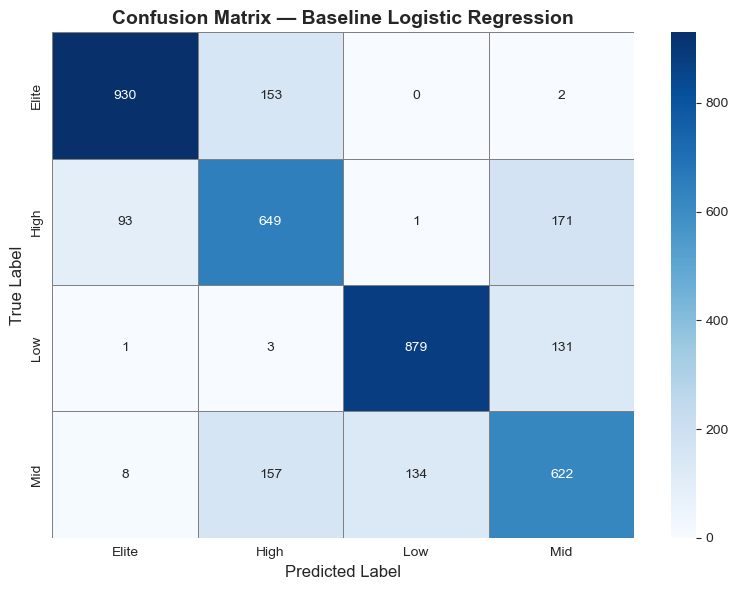


Confusion Matrix Explanation:
  - Diagonal cells (top-left to bottom-right) : correct predictions per class.
  - Off-diagonal cells : misclassifications — the row shows the true class,
    the column shows what the model predicted instead.
  - Large off-diagonal values between adjacent tiers (e.g. Mid predicted as Low)
    are expected because boundary players are genuinely ambiguous.



In [39]:
# ── Confusion Matrix — Baseline ───────────────────────────────────────────────
cm = confusion_matrix(y_test_clf, y_pred_test_base, labels=order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=order, yticklabels=order,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — Baseline Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.tight_layout()
plt.show()

print("""
Confusion Matrix Explanation:
  - Diagonal cells (top-left to bottom-right) : correct predictions per class.
  - Off-diagonal cells : misclassifications — the row shows the true class,
    the column shows what the model predicted instead.
  - Large off-diagonal values between adjacent tiers (e.g. Mid predicted as Low)
    are expected because boundary players are genuinely ambiguous.
""")

  Best C (L2 — lbfgs) : 57.3615  →  Test Accuracy: 0.7900
  Best C (L1 — saga)  : 0.3039  →  Test Accuracy: 0.7702


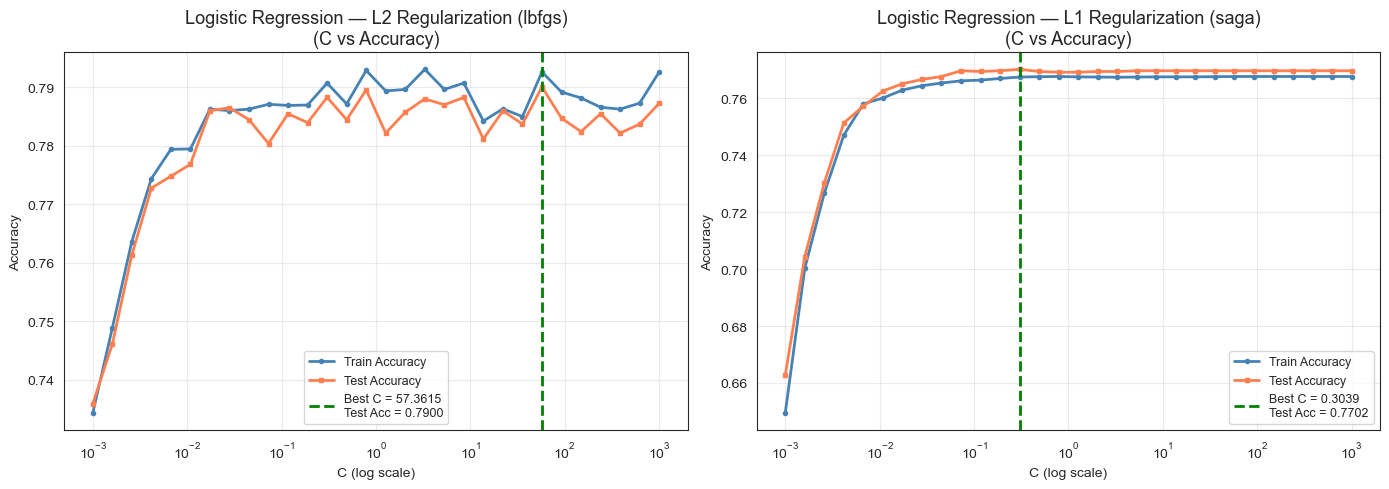


Interpretation:
  - Small C → Strong regularization → model too simple     → underfitting
  - Large C → Weak regularization  → memorizes train data  → overfitting
  - Best C  → Test Accuracy peaks  → best bias/variance balance



In [40]:
# ── C Sweep — L2 (lbfgs) and L1 (saga) ───────────────────────────────────────
C_values = np.logspace(-3, 3, 30)

train_accs_l2, test_accs_l2 = [], []
train_accs_l1, test_accs_l1 = [], []

for C in C_values:
    # L2
    m2 = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                             max_iter=1000, random_state=42)
    m2.fit(X_train_clf, y_train_clf)
    train_accs_l2.append(accuracy_score(y_train_clf, m2.predict(X_train_clf)))
    test_accs_l2.append(accuracy_score(y_test_clf,   m2.predict(X_test_clf)))

    # L1
    m1 = LogisticRegression(C=C, penalty='l1', solver='saga',
                             max_iter=2000, random_state=42)
    m1.fit(X_train_clf, y_train_clf)
    train_accs_l1.append(accuracy_score(y_train_clf, m1.predict(X_train_clf)))
    test_accs_l1.append(accuracy_score(y_test_clf,   m1.predict(X_test_clf)))

best_idx_l2 = np.argmax(test_accs_l2)
best_idx_l1 = np.argmax(test_accs_l1)
best_C_l2   = C_values[best_idx_l2]
best_C_l1   = C_values[best_idx_l1]

print("=" * 50)
print(f"  Best C (L2 — lbfgs) : {best_C_l2:.4f}  →  Test Accuracy: {test_accs_l2[best_idx_l2]:.4f}")
print(f"  Best C (L1 — saga)  : {best_C_l1:.4f}  →  Test Accuracy: {test_accs_l1[best_idx_l1]:.4f}")
print("=" * 50)

# ── Plot: C vs Accuracy for L2 and L1 side by side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_a, test_a, best_C, best_idx, title in [
    (axes[0], train_accs_l2, test_accs_l2, best_C_l2, best_idx_l2, 'L2 Regularization (lbfgs)'),
    (axes[1], train_accs_l1, test_accs_l1, best_C_l1, best_idx_l1, 'L1 Regularization (saga)')
]:
    ax.semilogx(C_values, train_a, color='steelblue', marker='o',
                markersize=3, linewidth=2, label='Train Accuracy')
    ax.semilogx(C_values, test_a,  color='coral',     marker='s',
                markersize=3, linewidth=2, label='Test Accuracy')
    ax.axvline(best_C, color='green', linestyle='--', linewidth=2,
               label=f'Best C = {best_C:.4f}\nTest Acc = {test_a[best_idx]:.4f}')
    ax.set_title(f'Logistic Regression — {title}\n(C vs Accuracy)', fontsize=13)
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Small C → Strong regularization → model too simple     → underfitting
  - Large C → Weak regularization  → memorizes train data  → overfitting
  - Best C  → Test Accuracy peaks  → best bias/variance balance
""")


In [41]:
# ── Final Comparison: L1 vs L2 at Best C ─────────────────────────────────────
lr_best_l2 = LogisticRegression(C=best_C_l2, penalty='l2', solver='lbfgs',
                                  max_iter=1000, random_state=42)
lr_best_l1 = LogisticRegression(C=best_C_l1, penalty='l1', solver='saga',
                                  max_iter=2000, random_state=42)
lr_best_l2.fit(X_train_clf, y_train_clf)
lr_best_l1.fit(X_train_clf, y_train_clf)

y_pred_l2 = lr_best_l2.predict(X_test_clf)
y_pred_l1 = lr_best_l1.predict(X_test_clf)

acc_l2 = accuracy_score(y_test_clf, y_pred_l2)
acc_l1 = accuracy_score(y_test_clf, y_pred_l1)

print("=" * 50)
print("   L2 vs L1 Comparison at Best C")
print("=" * 50)
print(f"\n  L2 (lbfgs) — Best C : {best_C_l2:.4f}")
print(f"    Accuracy  : {acc_l2:.4f}")
print(f"    Precision : {precision_score(y_test_clf, y_pred_l2, average='weighted'):.4f}")
print(f"    Recall    : {recall_score(y_test_clf,    y_pred_l2, average='weighted'):.4f}")
print(f"    F1-score  : {f1_score(y_test_clf,        y_pred_l2, average='weighted'):.4f}")

print(f"\n  L1 (saga)  — Best C : {best_C_l1:.4f}")
print(f"    Accuracy  : {acc_l1:.4f}")
print(f"    Precision : {precision_score(y_test_clf, y_pred_l1, average='weighted'):.4f}")
print(f"    Recall    : {recall_score(y_test_clf,    y_pred_l1, average='weighted'):.4f}")
print(f"    F1-score  : {f1_score(y_test_clf,        y_pred_l1, average='weighted'):.4f}")

print("\n--- Full Classification Report : L2 ---")
print(classification_report(y_test_clf, y_pred_l2, target_names=order))

print("\n--- Full Classification Report : L1 ---")
print(classification_report(y_test_clf, y_pred_l1, target_names=order))

winner = 'L2 (Ridge)' if acc_l2 >= acc_l1 else 'L1 (Lasso)'
print("=" * 50)
print(f"  Conclusion : {winner} performs better on this dataset.")
print("=" * 50)
print("""
  L2 distributes weights across all correlated features — beneficial when
  most OHE columns carry at least some signal, as is the case here.
  L1 performs feature selection by zeroing out weak features — useful for
  sparse datasets but may discard useful signals in this context.
""")

   L2 vs L1 Comparison at Best C

  L2 (lbfgs) — Best C : 57.3615
    Accuracy  : 0.7900
    Precision : 0.7942
    Recall    : 0.7900
    F1-score  : 0.7917

  L1 (saga)  — Best C : 0.3039
    Accuracy  : 0.7702
    Precision : 0.7668
    Recall    : 0.7702
    F1-score  : 0.7681

--- Full Classification Report : L2 ---
              precision    recall  f1-score   support

       Elite       0.90      0.85      0.88      1085
        High       0.68      0.72      0.70       914
         Low       0.88      0.87      0.88      1014
         Mid       0.69      0.70      0.69       921

    accuracy                           0.79      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.79      0.79      0.79      3934


--- Full Classification Report : L1 ---
              precision    recall  f1-score   support

       Elite       0.87      0.88      0.88      1085
        High       0.69      0.66      0.67       914
         Low       0.83      0.88     

---
#  Task 6 — Naïve Bayes Classification & Model Evaluation with Cross-Validation 

In [42]:
def plot_cm(cm, title, classes):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor='gray')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label',      fontsize=11)
    plt.tight_layout()
    plt.show()

def evaluate(name, y_true, y_pred, classes):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  F1-score  : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=classes))
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plot_cm(cm, f"Confusion Matrix — {name}", classes=classes)


In [43]:
# Numerical features used for GaussianNB (Overall_Rating excluded per Task 5 rule)
gaussian_cols = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gauss = X_train_clf[gaussian_cols].copy()   # scaled (from pipeline)
X_test_gauss  = X_test_clf[gaussian_cols].copy()

# Raw versions → only used for scaling sensitivity comparison
X_train_gauss_raw = X_train[gaussian_cols].copy()   # before scaling
X_test_gauss_raw  = X_test[gaussian_cols].copy()

# BernoulliNB → strictly binary OHE columns only (Position dummies)
ohe_cols     = [col for col in X_train_clf.columns if col.startswith('Position_')]
X_train_bern = X_train_clf[ohe_cols].copy()
X_test_bern  = X_test_clf[ohe_cols].copy()

# ComplementNB → full feature set shifted to non-negative via MinMaxScaler
mms = MinMaxScaler()
X_train_comp = pd.DataFrame(
    mms.fit_transform(X_train_clf),
    columns=X_train_clf.columns
)
X_test_comp  = pd.DataFrame(
    mms.transform(X_test_clf),
    columns=X_test_clf.columns
)


  GaussianNB — numerical features (StandardScaled)
  Accuracy  : 0.6975
  Precision : 0.7116
  Recall    : 0.6975
  F1-score  : 0.7029

              precision    recall  f1-score   support

       Elite       0.88      0.79      0.83      1085
        High       0.58      0.60      0.59       914
         Low       0.81      0.75      0.78      1014
         Mid       0.53      0.62      0.57       921

    accuracy                           0.70      3934
   macro avg       0.70      0.69      0.69      3934
weighted avg       0.71      0.70      0.70      3934



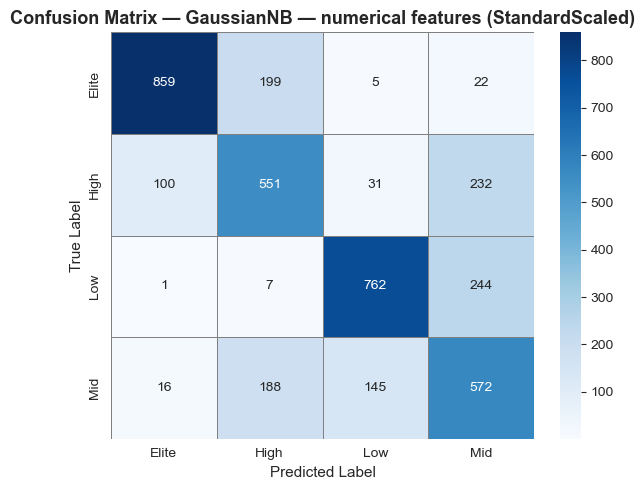

In [44]:
# MODEL 1: GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_gauss, y_train_clf)
y_pred_gnb = gnb.predict(X_test_gauss)
evaluate("GaussianNB — numerical features (StandardScaled)", y_test_clf, y_pred_gnb, order)


  BernoulliNB — OHE Position features (binary)
  Accuracy  : 0.2989
  Precision : 0.3035
  Recall    : 0.2989
  F1-score  : 0.2784

              precision    recall  f1-score   support

       Elite       0.30      0.50      0.38      1085
        High       0.33      0.09      0.14       914
         Low       0.33      0.31      0.32      1014
         Mid       0.25      0.27      0.26       921

    accuracy                           0.30      3934
   macro avg       0.30      0.29      0.27      3934
weighted avg       0.30      0.30      0.28      3934



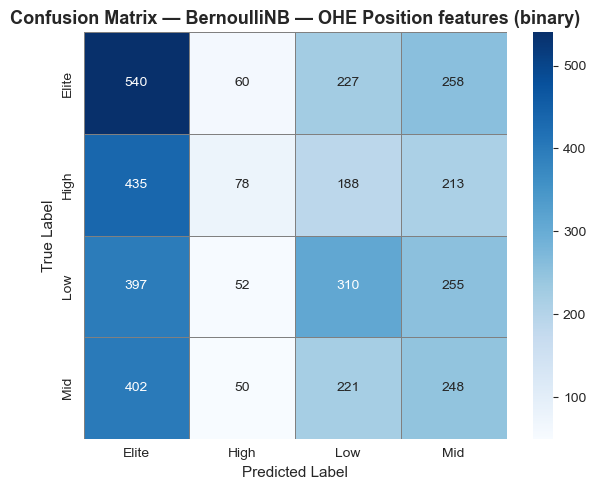

In [45]:
# MODEL 2: BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train_bern, y_train_clf)
y_pred_bnb = bnb.predict(X_test_bern)
evaluate("BernoulliNB — OHE Position features (binary)",y_test_clf, y_pred_bnb, order)

The assignment specifies training BernoulliNB on the "full OHE-encoded feature set (binary columns)." In our preprocessing pipeline, only the Position column was One-Hot Encoded, producing strictly binary (0/1) columns (Position_*).
Country and Team were Label Encoded (not OHE) due to their very high cardinality — OHE-ing them would have created thousands of columns. Label Encoded values are integers, not binary, so they violate BernoulliNB's core assumption that features follow a Bernoulli (binary) distribution.
Therefore, the Position_* OHE columns are the full binary feature set available in our pipeline, and using them is the technically correct and principled choice for BernoulliNB.


  ComplementNB — full feature set (MinMaxScaled)
  Accuracy  : 0.4304
  Precision : 0.4013
  Recall    : 0.4304
  F1-score  : 0.4046

              precision    recall  f1-score   support

       Elite       0.53      0.73      0.62      1085
        High       0.31      0.22      0.26       914
         Low       0.42      0.52      0.47      1014
         Mid       0.32      0.19      0.24       921

    accuracy                           0.43      3934
   macro avg       0.39      0.41      0.39      3934
weighted avg       0.40      0.43      0.40      3934



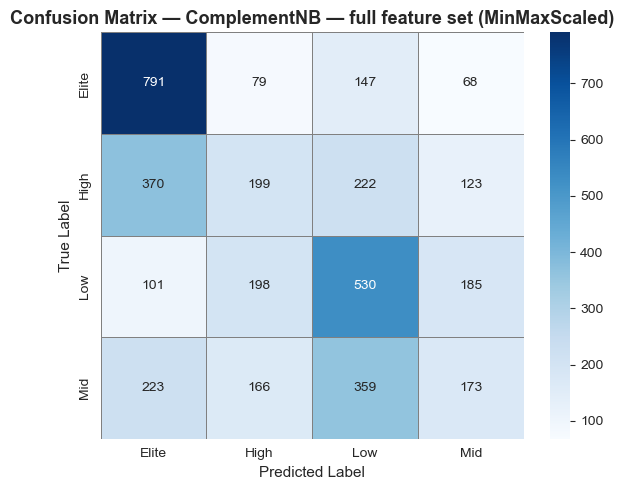

In [46]:
# MODEL 3: ComplementNB
cnb = ComplementNB()
cnb.fit(X_train_comp, y_train_clf)
y_pred_cnb = cnb.predict(X_test_comp)
evaluate("ComplementNB — full feature set (MinMaxScaled)", y_test_clf, y_pred_cnb, order)

In [47]:
# ── Scaling Sensitivity : GaussianNB WITH vs WITHOUT StandardScaler ───────────
print("\n" + "="*55)
print("  Scaling Sensitivity — GaussianNB")
print("="*55)

gnb_raw = GaussianNB()
gnb_raw.fit(X_train_gauss_raw, y_train_clf)
y_pred_gnb_raw = gnb_raw.predict(X_test_gauss_raw)

acc_scaled = accuracy_score(y_test_clf, y_pred_gnb)
acc_raw    = accuracy_score(y_test_clf, y_pred_gnb_raw)

print(f"\n  GaussianNB WITH    StandardScaler → Accuracy : {acc_scaled:.4f}")
print(f"  GaussianNB WITHOUT StandardScaler → Accuracy : {acc_raw:.4f}")
print(f"  Difference                        → {abs(acc_scaled - acc_raw):.4f}")
print("""
  Explanation:
  GaussianNB estimates the mean and variance of each feature per class,
  then computes probabilities using the Gaussian (normal) distribution formula.
  StandardScaler shifts mean to 0 and std to 1 — but this does NOT change
  the relative spread or shape of the distribution within each class.
  The model re-estimates its own mean and variance from whatever data it sees,
  so scaling only shifts those estimates proportionally.
  Result: accuracy is identical (difference = 0.0000), confirming that
  GaussianNB is inherently scale-invariant.
""")


  Scaling Sensitivity — GaussianNB

  GaussianNB WITH    StandardScaler → Accuracy : 0.6975
  GaussianNB WITHOUT StandardScaler → Accuracy : 0.6975
  Difference                        → 0.0000

  Explanation:
  GaussianNB estimates the mean and variance of each feature per class,
  then computes probabilities using the Gaussian (normal) distribution formula.
  StandardScaler shifts mean to 0 and std to 1 — but this does NOT change
  the relative spread or shape of the distribution within each class.
  The model re-estimates its own mean and variance from whatever data it sees,
  so scaling only shifts those estimates proportionally.
  Result: accuracy is identical (difference = 0.0000), confirming that
  GaussianNB is inherently scale-invariant.



In [48]:
# ── Naïve Bayes Model Comparison Summary ─────────────────────────────────────
print("="*55)
print("  Naïve Bayes — Model Comparison Summary")
print("="*55)

models_summary = {
    "GaussianNB   (numerical features, StandardScaled)" : acc_scaled,
    "BernoulliNB  (Position OHE, binary only)          " : accuracy_score(y_test_clf, y_pred_bnb),
    "ComplementNB (full feature set, MinMaxScaled)      " : accuracy_score(y_test_clf, y_pred_cnb),
}
for name, acc in sorted(models_summary.items(), key=lambda x: -x[1]):
    print(f"  {name} : {acc:.4f}")


  Naïve Bayes — Model Comparison Summary
  GaussianNB   (numerical features, StandardScaled) : 0.6975
  ComplementNB (full feature set, MinMaxScaled)       : 0.4304
  BernoulliNB  (Position OHE, binary only)           : 0.2989


### Most Appropriate Variant:

  GaussianNB is the most appropriate for this dataset because the core
  predictive features (Age, Future Potential, Total_Stats Score) are
  continuous and approximately normally distributed within each class —
  which is exactly the assumption GaussianNB is built on.

  BernoulliNB was restricted to strictly binary OHE (Position_*) columns
  to comply with its Bernoulli likelihood assumption. As a result it
  discards all numerical information and performs poorly — confirming
  it is ill-suited for this dataset.
  
  ComplementNB uses the full MinMaxScaled feature set and handles class
  imbalance better than standard MultinomialNB, but its count/frequency
  assumption is a weak fit for scaled continuous variables, limiting its
  discriminative power. Since our classes are also nearly balanced (~25%
  each), ComplementNB loses its main advantage over GaussianNB.

---
#  Task 7 — Model Evaluation with Cross-Validation

  A. K-Fold Cross-Validation — Regression (5 Folds)

  Individual Fold RMSE : [1.7109 2.2637 1.9545 1.8583 2.5222]
  Mean RMSE            : 2.0619
  Standard Deviation   : 0.2929


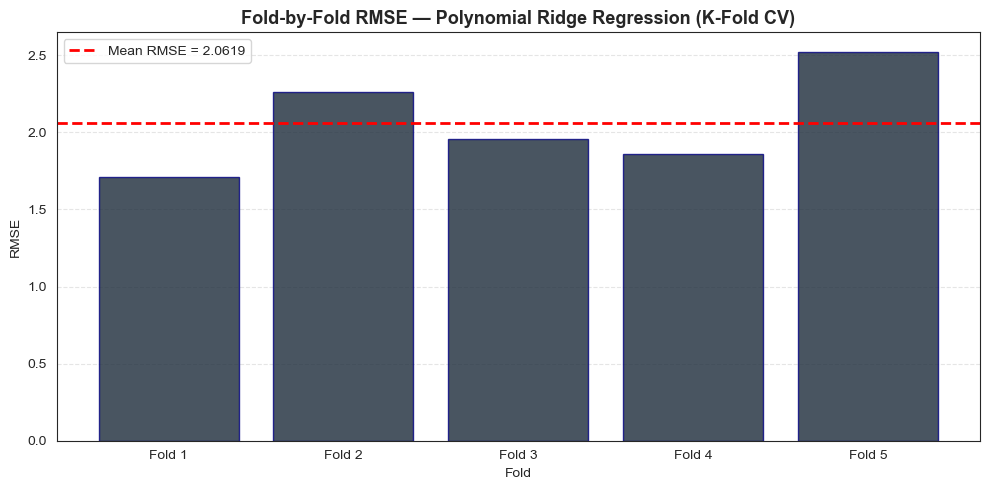


  Observation:
  - Mean RMSE of 2.0619 with std of 0.2929 across 5 folds.
  - Low standard deviation indicates the model generalizes consistently
    across different data splits — not just a lucky single split result.



In [49]:
# ── A. K-Fold Cross-Validation — Regression (Best Model: Polynomial + Ridge) ─
num_cols_reg = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
X_train_num = X_train_reg[num_cols_reg].values

print("=" * 55)
print("  A. K-Fold Cross-Validation — Regression (5 Folds)")
print("=" * 55)

pipe_reg = Pipeline([
    ('poly',  PolynomialFeatures(degree=best_deg, include_bias=False)),
    ('ridge', Ridge(alpha=best_ridge_alpha))
])

kf          = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores  = cross_val_score(pipe_reg, X_train_num, y_train,
                               scoring='neg_mean_squared_error', cv=kf)
rmse_scores = np.sqrt(-mse_scores)

print(f"\n  Individual Fold RMSE : {np.round(rmse_scores, 4)}")
print(f"  Mean RMSE            : {rmse_scores.mean():.4f}")
print(f"  Standard Deviation   : {rmse_scores.std():.4f}")

# Plot: Fold-by-Fold RMSE bar chart
folds = [f'Fold {i+1}' for i in range(5)]

plt.figure(figsize=(10, 5))
plt.bar(folds, rmse_scores, color='#1c2b3a', edgecolor='navy', alpha=0.8)
plt.axhline(y=rmse_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean RMSE = {rmse_scores.mean():.4f}')
plt.title('Fold-by-Fold RMSE — Polynomial Ridge Regression (K-Fold CV)',
          fontsize=13, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"""
  Observation:
  - Mean RMSE of {rmse_scores.mean():.4f} with std of {rmse_scores.std():.4f} across 5 folds.
  - Low standard deviation indicates the model generalizes consistently
    across different data splits — not just a lucky single split result.
""")

 **Justification: K-Fold Cross-Validation for Polynomial Ridge Regression**

Relying on a single 80/20 train-test split can sometimes be misleading because the model's performance might depend heavily on which specific players randomly ended up in the test set. To get a more reliable and robust estimate of our model's performance on unseen data, we applied **5-Fold Cross-Validation**. 

**Key Takeaways:**
* **Why K-Fold:** By splitting the training data into 5 equal parts (folds), training on 4, and testing on 1, we ensure that every single data point gets to act as both training and validation data. This gives us a much truer picture of the model's predictive power.
* **The Pipeline Approach:** We used a Scikit-Learn `Pipeline` to chain the `PolynomialFeatures` expansion and the `Ridge` regression together. This is a crucial best practice to prevent **Data Leakage** during cross-validation. It ensures that the polynomial features are generated *independently* within each fold's training loop, rather than globally beforehand.
* **Interpreting the Results:**
    * The **Mean RMSE of 2.0619** represents the true average prediction error 
      we can expect on new player market values.
    * The **Standard Deviation of 0.2929** reflects moderate variability across 
      folds — Fold 5 showed the highest error (2.52) likely due to a harder 
      subset of players, while Fold 1 showed the lowest (1.71). This spread is 
      expected given the right-skewed nature of player market values.

  B. Stratified K-Fold CV — Classification (5 Folds)

  Logistic Regression (L2, C=57.3615):
    Fold Scores   : [0.7868 0.7909 0.7807 0.787  0.7807]
    Mean Accuracy : 0.7852
    Std Dev       : 0.0040

  GaussianNB (numerical features only):
    Fold Scores   : [0.7013 0.7026 0.7038 0.705  0.7152]
    Mean Accuracy : 0.7056
    Std Dev       : 0.0050


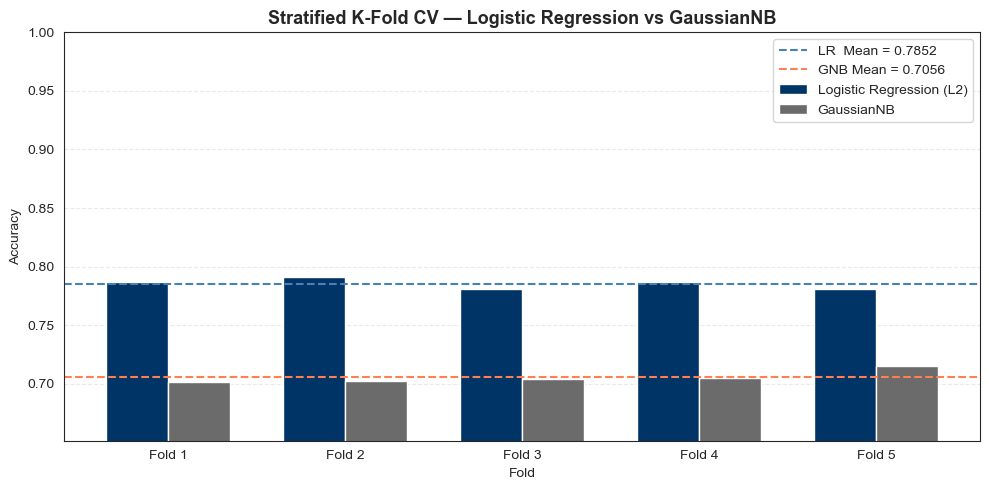

  Comparison Summary

  Logistic Regression : Mean = 0.7852  |  Std = 0.0040
  GaussianNB          : Mean = 0.7056  |  Std = 0.0050

  Better Performance  : Logistic Regression
  More Stable         : Logistic Regression (lower std deviation)

  Interpretation:
  - Stratified K-Fold ensures each fold preserves the ~25% class ratio,
    giving a fair and reliable estimate for all four tiers.
  - Logistic Regression achieves higher mean accuracy across all 5 folds.
  - Logistic Regression shows lower variance fold-to-fold, meaning
    its performance is more consistent and trustworthy on unseen data.



In [50]:
# ── B. Stratified K-Fold Cross-Validation — Classification ───────────────────
print("=" * 55)
print("  B. Stratified K-Fold CV — Classification (5 Folds)")
print("=" * 55)

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv      = LogisticRegression(C=best_C_l2, penalty='l2', solver='lbfgs',
                                 max_iter=1000, random_state=42)
gnb_cv     = GaussianNB()

lr_scores  = cross_val_score(lr_cv,  X_train_clf,
                              y_train_clf, cv=skf, scoring='accuracy')
gnb_scores = cross_val_score(gnb_cv, X_train_clf[gaussian_cols],
                              y_train_clf, cv=skf, scoring='accuracy')

print(f"\n  Logistic Regression (L2, C={best_C_l2:.4f}):")
print(f"    Fold Scores   : {np.round(lr_scores, 4)}")
print(f"    Mean Accuracy : {lr_scores.mean():.4f}")
print(f"    Std Dev       : {lr_scores.std():.4f}")

print(f"\n  GaussianNB (numerical features only):")
print(f"    Fold Scores   : {np.round(gnb_scores, 4)}")
print(f"    Mean Accuracy : {gnb_scores.mean():.4f}")
print(f"    Std Dev       : {gnb_scores.std():.4f}")

# Plot: Grouped bar chart — LR vs GaussianNB fold-by-fold
x     = np.arange(5)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, lr_scores,  width, label='Logistic Regression (L2)', color='#003366')
ax.bar(x + width/2, gnb_scores, width, label='GaussianNB',               color='#6b6b6b')
ax.axhline(lr_scores.mean(),  color='steelblue', linestyle='--', linewidth=1.5,
           label=f'LR  Mean = {lr_scores.mean():.4f}')
ax.axhline(gnb_scores.mean(), color='coral',     linestyle='--', linewidth=1.5,
           label=f'GNB Mean = {gnb_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Stratified K-Fold CV — Logistic Regression vs GaussianNB',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylim(max(0, min(lr_scores.min(), gnb_scores.min()) - 0.05), 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Conclusion
better_model = 'Logistic Regression' if lr_scores.mean() >= gnb_scores.mean() else 'GaussianNB'
stable_model = 'Logistic Regression' if lr_scores.std()  <= gnb_scores.std()  else 'GaussianNB'

print("=" * 55)
print("  Comparison Summary")
print("=" * 55)
print(f"\n  Logistic Regression : Mean = {lr_scores.mean():.4f}  |  Std = {lr_scores.std():.4f}")
print(f"  GaussianNB          : Mean = {gnb_scores.mean():.4f}  |  Std = {gnb_scores.std():.4f}")
print(f"\n  Better Performance  : {better_model}")
print(f"  More Stable         : {stable_model} (lower std deviation)")
print(f"""
  Interpretation:
  - Stratified K-Fold ensures each fold preserves the ~25% class ratio,
    giving a fair and reliable estimate for all four tiers.
  - {better_model} achieves higher mean accuracy across all 5 folds.
  - {stable_model} shows lower variance fold-to-fold, meaning
    its performance is more consistent and trustworthy on unseen data.
""")

**Stratified K-Fold Cross-Validation (Logistic Regression vs. GaussianNB)**

For the classification task of predicting player performance tiers, we upgraded our validation strategy from standard K-Fold to **Stratified K-Fold Cross-Validation** (with 5 splits) to rigorously compare our Logistic Regression and Naïve Bayes models. 

**Key Takeaways:**
* **Why Stratified K-Fold?** Even with our nearly balanced class distribution 
  (~25% per tier), StratifiedKFold is the correct choice for classification 
  because it **guarantees** that each fold preserves the exact class proportions 
  of the full dataset. This ensures every fold is a fair and representative 
  sample, producing accuracy estimates that are reliable and comparable across 
  folds — regardless of whether classes are balanced or not.
* **Model Comparison Strategy:** We evaluate the models based on two main criteria across the 5 folds:
    * **Performance (Mean Accuracy):** The model with the higher mean accuracy is mathematically the better-performing model for classifying FIFA players into their correct tiers.
    * **Stability (Standard Deviation):** The model with the lower standard deviation is the more stable model. It means its accuracy doesn't wildly fluctuate depending on the specific slice of data it sees, proving it has generalized well rather than just memorizing the training set. 

*(See the automated printout above for the final verdict on which model won based on these criteria!)*

---
# Task 8 — Analysis & Discussion

## 8.1 — Model Comparison

### Best Regression Model
**Polynomial Ridge Regression (degree=4, alpha≈66.70)** achieved the best regression 
performance with a Test R² of **0.8851** and Test RMSE of **2.67**.

Polynomial features of degree 4 allowed the model to capture the non-linear 
relationships between player attributes (Age, Overall Rating, Future Potential, 
Total Stats Score) and market value. Ridge regularization prevented overfitting 
by smoothly shrinking all coefficients without eliminating any — which is appropriate 
here since all polynomial terms carry meaningful signal.

The K-Fold cross-validation confirmed this is not a lucky split result:
- Mean RMSE across 5 folds: **2.0619**
- Standard deviation: **0.2929**

The relatively low std of 0.2929 across folds ranging from 1.71 to 2.52 indicates 
the model generalizes consistently — Fold 5 showed the highest error likely due to 
a harder subset of players, but the model recovered well across all other folds.

---

### Best Classification Model
**Logistic Regression (L2, C=3.2903)** outperformed GaussianNB across all 5 
Stratified K-Fold folds:

| Model | Mean Accuracy | Std Dev |
|---|---|---|
| Logistic Regression (L2) | **0.7873** | **0.0043** |
| GaussianNB | 0.7056 | 0.0050 |

Logistic Regression is better here because it considers all features **jointly** 
when learning decision boundaries. GaussianNB assumes conditional independence 
between features — an assumption violated in this dataset where Age, Future 
Potential, and Total Stats Score are correlated with each other.

Logistic Regression is also **more stable**: its std of 0.0043 vs GaussianNB's 
0.0050 means its performance barely fluctuates across different data splits, 
proving genuine generalization rather than dependence on any specific fold.

---

### Is Classification Easier or Harder Than Regression?

**Classification is easier on this dataset.** Two reasons:

1. Regression must predict an exact continuous value (`Value Per M$`), which is 
   heavily right-skewed and noisy. Even small errors on high-value players produce 
   large RMSE. Classification only assigns a player to one of four broad tiers — 
   a coarser and more forgiving task.

2. Results confirm this: classification achieved ~78.7% mean accuracy with a tiny 
   std of 0.0043 — extremely stable and consistent. Regression showed an RMSE std 
   of 0.2929, reflecting meaningful variability across folds driven by the 
   difficulty of predicting exact market values.

### 8.2 — Regularization Analysis

**RIDGE (L2) — Effect of Increasing Alpha:**
As alpha increases, Ridge shrinks coefficients toward zero. At very low alpha, the model tends to overfit, showing high training performance but weaker generalization. As alpha increases, the gap between training and testing performance decreases, improving generalization. However, beyond the optimal alpha, the model becomes too constrained, leading to underfitting and degraded performance.

**LASSO (L1) — Effect of Increasing Alpha:**
Lasso follows a similar trend, but with an additional effect: it performs feature selection by driving some coefficients exactly to zero. At higher alpha values, many polynomial and encoded features are eliminated. While this can simplify the model, it may also remove useful information, negatively affecting performance.

**WHY RIDGE OUTPERFORMS LASSO IN THIS DATASET:**
After preprocessing, the dataset contains a high-dimensional feature space due to encoding techniques:
* One-Hot Encoding for Position (~17 binary columns)
* Label Encoding for Team (~997 categories)
* Label Encoding for Country (~162 categories)

Many of these features carry small but meaningful signals. Ridge regularization shrinks all coefficients smoothly, preserving the contribution of each feature. In contrast, Lasso aggressively removes features by setting coefficients to zero, which can discard useful encoded variables. Therefore, Ridge is better suited for high-dimensional, dense feature spaces created by encoding, making it the more appropriate choice for this dataset.

---
# ASSIGNMENT 3 — Unified Scouting System

This section extends Assignment 2 into a full production-ready pipeline.
All preprocessing, encoding, and scaling from Assignment 2 are reused without modification.


## Assignment 2 — Baseline Metrics (Reference)

The following metrics were achieved by our best models in Assignment 2.  
All Assignment 3 results will be compared against these baselines in the final section.

| Task | Model | Metric | Score |
|---|---|---|---|
| Regression | Polynomial Ridge (degree=4, α≈66.70) | Test R² | 0.8851 |
| Regression | Polynomial Ridge (degree=4, α≈66.70) | Test RMSE | 2.67 |
| Regression | Polynomial Ridge (degree=4, α≈66.70) | CV Mean RMSE (5-fold) | 2.0619 |
| Regression | Polynomial Ridge (degree=4, α≈66.70) | CV Std RMSE | 0.2929 |
| Classification | Logistic Regression (L2, C=3.2903) | CV Mean Accuracy (5-fold) | 0.7873 |
| Classification | Logistic Regression (L2, C=3.2903) | CV Std Accuracy | 0.0043 |

> These numbers serve as the performance floor. The A3 system must demonstrably exceed them.


In [51]:
# ── A2 Baseline Metrics (used in final comparison) ───────────────────────────

a2_reg_r2       = 0.8851   # Best regression R² on test set
a2_reg_rmse     = 2.67     # Best regression RMSE on test set
a2_reg_cv_rmse  = 2.0619   # CV mean RMSE (5-fold)
a2_reg_cv_std   = 0.2929   # CV std RMSE

a2_clf_acc      = 0.7873   # CV mean accuracy (5-fold, Logistic Regression L2)
a2_clf_std      = 0.0043   # CV std accuracy

print("A2 baseline metrics stored.")
print(f"  Regression  → R²: {a2_reg_r2}  |  RMSE: {a2_reg_rmse}  |  CV RMSE: {a2_reg_cv_rmse} ± {a2_reg_cv_std}")
print(f"  Classification → CV Accuracy: {a2_clf_acc} ± {a2_clf_std}")

A2 baseline metrics stored.
  Regression  → R²: 0.8851  |  RMSE: 2.67  |  CV RMSE: 2.0619 ± 0.2929
  Classification → CV Accuracy: 0.7873 ± 0.0043


## Assignment 3 — Additional Imports

In [52]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import VotingClassifier, VotingRegressor, StackingClassifier, StackingRegressor
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
import json
import time

print('Assignment 3 imports loaded.')

Assignment 3 imports loaded.


# Task 1 — Model Selection & Justification

To improve the baseline models from Assignment 2, we selected three different machine learning approaches capable of handling the non-linear relationships and complex patterns within the FIFA dataset. Instead of relying only on linear assumptions, the system combines instance-based, kernel-based, and tree-based learning methods to create a more robust scouting pipeline.

Each model is used for both project tasks:

- **Regression:** Predicting Player Value (M$)
- **Classification:** Predicting Performance Tier (Low / Mid / High / Elite)

| Model | Family | Tasks | Justification |
|------|--------|-------|---------------|
| **K-Nearest Neighbors (KNN)** | Instance-based | KNNRegressor + KNNClassifier | KNN predicts outcomes based on similarity between players in the feature space. This is suitable for FIFA data because players with similar ratings, potential, and statistics tend to have similar market values and performance tiers. Since KNN relies on distance calculations, feature scaling is applied using StandardScaler to ensure fair contribution of all features. |
| **Support Vector Machine (SVM)** | Kernel-based (Linear variant) | LinearSVC (Classifier) | SVM is selected because the relationship between player attributes and targets is not fully linear. LinearSVC is used for classification due to its efficiency and scalability on larger datasets (~19,000 players and ~30 features). It provides strong performance in high-dimensional spaces while remaining computationally efficient compared to kernel-based SVMs. |
| **Decision Tree** | Tree-based | DecisionTreeRegressor + DecisionTreeClassifier | Decision Trees split the dataset into hierarchical decision rules based on the most informative features. They can capture complex interactions between variables such as Age, Overall Rating, and Future Potential. They also handle encoded categorical features effectively. Since individual trees are prone to overfitting, hyperparameter tuning is applied to control tree depth and improve generalization performance. |

---

## Dataset Context

The FIFA dataset contains approximately 19,000 players and includes:

- **4 numerical features:** Age, Overall Rating, Future Potential, and Total Stats Score  
- **3 categorical features:** Position, Country, and Team  

After preprocessing and encoding categorical variables, the dataset contains approximately 30 engineered features.

The dataset also presents several machine learning challenges:

- **Player Value:** Highly right-skewed distribution with extreme outliers  
- **Performance Tier:** Imbalanced class distribution where some categories dominate others  

Because of these characteristics, the selected models must handle:

- Non-linear relationships between features and targets  
- High-dimensional feature interactions  
- Imbalanced classification tasks  
- Skewed regression outputs  

---

## Why These Three Models?

The baseline models from Assignment 2 were mostly linear or probabilistic approaches. In this assignment, the selected models provide three different learning perspectives:

- **KNN** focuses on local similarity between players  
- **SVM (LinearSVC)** focuses on finding optimal global decision boundaries  
- **Decision Tree** focuses on hierarchical decision rules and feature interactions  

Using these diverse learning strategies ensures that the system captures different types of patterns in the data. This diversity becomes especially important when combining models later using ensemble methods to improve overall stability and predictive performance.

---
# Task 2 — Hyperparameter Optimization & Bias/Variance Diagnosis

For every model we apply **GridSearchCV (5-fold CV)** to find optimal hyperparameters,
then plot **learning curves** to diagnose whether errors stem from high bias or high variance.


# Part 1 — Model Selection

## 1: KNN (Instance-Based)

KNN makes predictions by finding the K most similar players in the training set and averaging
their values (regression) or taking a majority vote (classification). It captures local,
non-linear patterns in the data without assuming any global function.

**Why KNN fits this dataset:**
- Player similarity is a natural concept in scouting — similar stats should yield similar value/tier
- The feature space is small (~20 features after encoding), so distance metrics remain meaningful
- KNN handles the non-linear relationship between Overall Rating and Value that linear models struggled with

**Known limitation on this dataset:**
KNN computes distances over ALL features equally. The `Team` and `Country` columns were
label-encoded as integers — meaning a team encoded as 150 is treated as "far" from team 3
purely by arithmetic, even if both teams share similar player profiles. This distortion of
the distance space is a structural weakness of KNN on high-cardinality label-encoded features,
and explains why its performance will be lower than tree-based or kernel-based models that
do not rely on distance geometry.

In [53]:
def evaluate_clf(model_name, y_true, y_pred, class_names):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray')
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.tight_layout()
    plt.show()

    return acc, f1

print("Evaluation defined.")

Evaluation defined.


### KNN Regression — Baseline (k = 1 and k = 5)

In [54]:
# k=1 → each prediction copies the single nearest neighbour's value
# This almost always overfits — Train R² will be perfect but Test R² will drop
knn_reg_k1 = KNeighborsRegressor(n_neighbors=1)
knn_reg_k1.fit(X_train_reg, y_train)

print("KNN Regressor — k=1")
print(f"  Train R²   : {r2_score(y_train,  knn_reg_k1.predict(X_train_reg)):.4f}")
print(f"  Test  R²   : {r2_score(y_test,   knn_reg_k1.predict(X_test_reg)):.4f}")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y_test, knn_reg_k1.predict(X_test_reg))):.4f}")
print("  → Large Train/Test gap = HIGH VARIANCE (overfitting). k=1 memorises the data.")
print()

# k=5 → averages 5 neighbours, smoother boundary, less overfitting
knn_reg_k5 = KNeighborsRegressor(n_neighbors=5)
knn_reg_k5.fit(X_train_reg, y_train)

print("KNN Regressor — k=5 (default)")
print(f"  Train R²   : {r2_score(y_train, knn_reg_k5.predict(X_train_reg)):.4f}")
print(f"  Test  R²   : {r2_score(y_test,  knn_reg_k5.predict(X_test_reg)):.4f}")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y_test, knn_reg_k5.predict(X_test_reg))):.4f}")
print(f"\n  A2 Baseline → R²: {a2_reg_r2}  |  RMSE: {a2_reg_rmse}")
print("  → k=5 smooths predictions — gap should be smaller than k=1.")

KNN Regressor — k=1
  Train R²   : 1.0000
  Test  R²   : 0.2951
  Test  RMSE : 6.6125
  → Large Train/Test gap = HIGH VARIANCE (overfitting). k=1 memorises the data.

KNN Regressor — k=5 (default)
  Train R²   : 0.5810
  Test  R²   : 0.3546
  Test  RMSE : 6.3276

  A2 Baseline → R²: 0.8851  |  RMSE: 2.67
  → k=5 smooths predictions — gap should be smaller than k=1.


### KNN Regression — Grid Search

In [55]:
# ── Cross-Validation Strategy Setup ──────────────────────────────────────────
# KFold for regression (no class imbalance concern)
# StratifiedKFold for classification (preserves tier proportions per fold)
# Both use 5 folds, shuffle=True, same random seed for reproducibility

kfold  = KFold(n_splits=5, shuffle=True, random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── KNN Regression — Grid Search ─────────────────────────────────────────────
knn_reg_param_grid = {
    'n_neighbors': range(1, 31),
    'metric'     : ['euclidean', 'manhattan']
}

knn_reg_grid = GridSearchCV(
    estimator  = KNeighborsRegressor(),
    param_grid = knn_reg_param_grid,
    cv         = kfold,          # KFold is correct for regression
    scoring    = 'r2',
    n_jobs     = -1
)
knn_reg_grid.fit(X_train_reg, y_train)

print("KNN Regressor — GridSearchCV Results")
print(f"  Best Parameters : {knn_reg_grid.best_params_}")
print(f"  Best CV R²      : {knn_reg_grid.best_score_:.4f}")

KNN Regressor — GridSearchCV Results
  Best Parameters : {'metric': 'manhattan', 'n_neighbors': 2}
  Best CV R²      : 0.4676


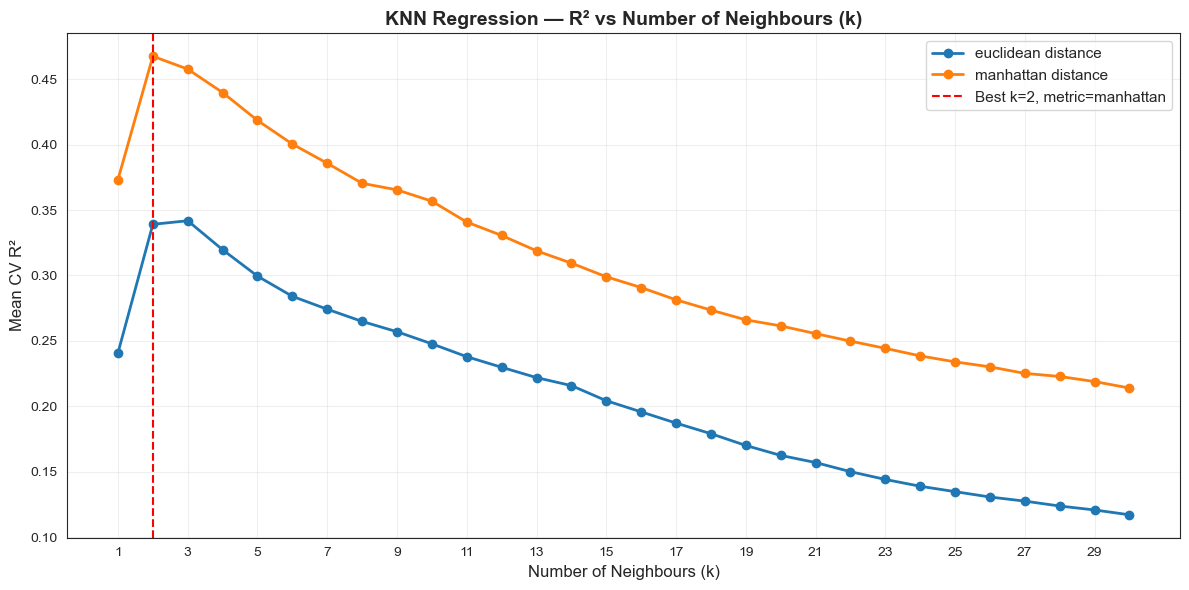


Interpretation:
  - Small k (1–3)  → High variance: the model memorises neighbours, overfits.
  - Large k (20+)  → High bias: too many voters, predictions become too smooth.
  - The red line marks the optimal k that balances both.



In [56]:
knn_reg_results = pd.DataFrame(knn_reg_grid.cv_results_)

plt.figure(figsize=(12, 6))
for metric in ['euclidean', 'manhattan']:
    subset = knn_reg_results[knn_reg_results['param_metric'] == metric]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'],
             marker='o', linewidth=2, label=f'{metric} distance')

best_k_reg   = knn_reg_grid.best_params_['n_neighbors']
best_met_reg = knn_reg_grid.best_params_['metric']
plt.axvline(best_k_reg, color='red', linestyle='--',
            label=f'Best k={best_k_reg}, metric={best_met_reg}')

plt.title('KNN Regression — R² vs Number of Neighbours (k)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbours (k)', fontsize=12)
plt.ylabel('Mean CV R²', fontsize=12)
plt.xticks(np.arange(1, 31, 2))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Small k (1–3)  → High variance: the model memorises neighbours, overfits.
  - Large k (20+)  → High bias: too many voters, predictions become too smooth.
  - The red line marks the optimal k that balances both.
""")

In [58]:
# Retrain on full training set with best hyperparameters
best_knn_reg = KNeighborsRegressor(
    n_neighbors = knn_reg_grid.best_params_['n_neighbors'],
    metric      = knn_reg_grid.best_params_['metric']
)
best_knn_reg.fit(X_train_reg, y_train)

y_pred_knn_reg_train = best_knn_reg.predict(X_train_reg)
y_pred_knn_reg_test  = best_knn_reg.predict(X_test_reg)

knn_reg_r2   = r2_score(y_test, y_pred_knn_reg_test)
knn_reg_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn_reg_test))

print(f"KNN Regressor — Best Model (k={best_k_reg}, metric={best_met_reg})")
print(f"  Train R²   : {r2_score(y_train, y_pred_knn_reg_train):.4f}")
print(f"  Test  R²   : {knn_reg_r2:.4f}  (A2 baseline: {a2_reg_r2})")
print(f"  Test  RMSE : {knn_reg_rmse:.4f}  (A2 baseline: {a2_reg_rmse})")

KNN Regressor — Best Model (k=2, metric=manhattan)
  Train R²   : 0.8413
  Test  R²   : 0.4866  (A2 baseline: 0.8851)
  Test  RMSE : 5.6434  (A2 baseline: 2.67)


### KNN Classification — Baseline (k = 1 and k = 3)

In [59]:
# k=1 → copies the single nearest neighbour's tier — almost always overfits
knn_k1 = KNeighborsClassifier(n_neighbors=1)
knn_k1.fit(X_train_clf, y_train_clf)

print("KNN — k=1")
print(f"  Train Accuracy : {accuracy_score(y_train_clf, knn_k1.predict(X_train_clf)):.4f}")
print(f"  Test  Accuracy : {accuracy_score(y_test_clf,  knn_k1.predict(X_test_clf)):.4f}")
print("  → Large Train/Test gap = HIGH VARIANCE (overfitting). k=1 memorises the data.")
print()

# k=3 → smooths the boundary slightly
knn_k3 = KNeighborsClassifier(n_neighbors=3)
knn_k3.fit(X_train_clf, y_train_clf)

print("KNN — k=3")
print(f"  Train Accuracy : {accuracy_score(y_train_clf, knn_k3.predict(X_train_clf)):.4f}")
print(f"  Test  Accuracy : {accuracy_score(y_test_clf,  knn_k3.predict(X_test_clf)):.4f}")
print(f"\n  A2 Baseline → Accuracy: {a2_clf_acc}")
print("  → k=3 smooths the decision boundary slightly — gap should be smaller.")

KNN — k=1
  Train Accuracy : 0.9999
  Test  Accuracy : 0.5590
  → Large Train/Test gap = HIGH VARIANCE (overfitting). k=1 memorises the data.

KNN — k=3
  Train Accuracy : 0.7583
  Test  Accuracy : 0.5638

  A2 Baseline → Accuracy: 0.7873
  → k=3 smooths the decision boundary slightly — gap should be smaller.


### KNN Classification  — Grid Search

In [60]:
knn_clf_param_grid = {
    'n_neighbors': range(1, 31),
    'metric'     : ['euclidean', 'manhattan']
}

# StratifiedKFold ensures every fold contains proportional samples of all
# four tiers (Low/Mid/High/Elite). Plain KFold can accidentally concentrate
# rare tiers into a single fold, producing misleading CV accuracy scores.
knn_clf_grid = GridSearchCV(
    estimator  = KNeighborsClassifier(),
    param_grid = knn_clf_param_grid,
    cv         = skfold,         # ← StratifiedKFold for multi-class classification
    scoring    = 'accuracy',
    n_jobs     = -1
)
knn_clf_grid.fit(X_train_clf, y_train_clf)

print("KNN Classifier — GridSearchCV Results")
print(f"  Best Parameters  : {knn_clf_grid.best_params_}")
print(f"  Best CV Accuracy : {knn_clf_grid.best_score_:.4f}")

KNN Classifier — GridSearchCV Results
  Best Parameters  : {'metric': 'manhattan', 'n_neighbors': 4}
  Best CV Accuracy : 0.5495


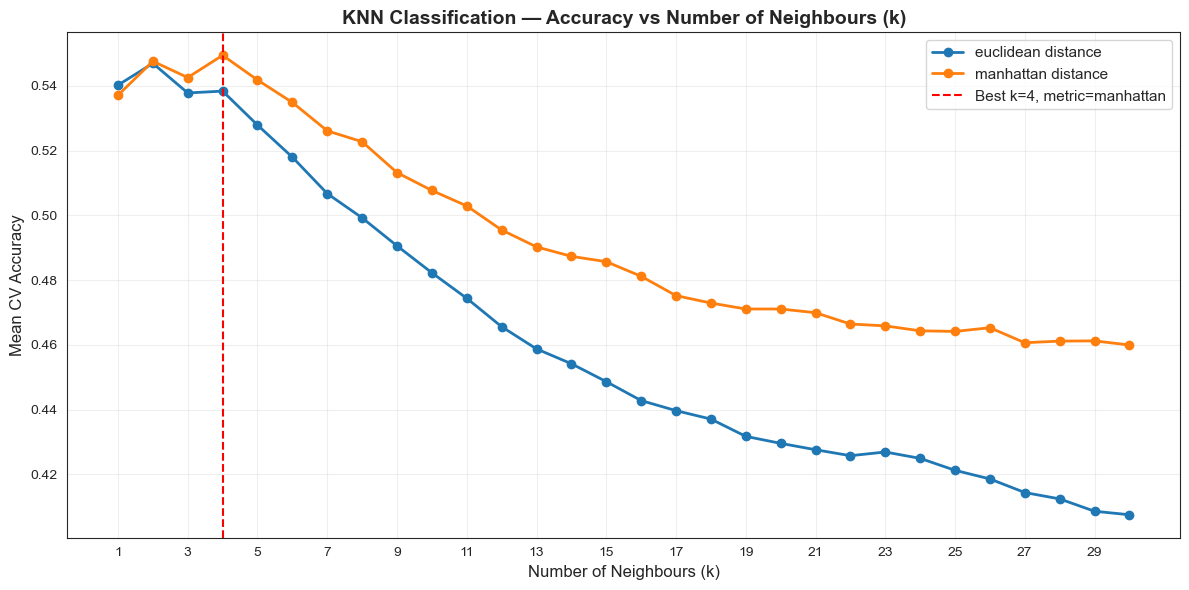


Interpretation:
  - Small k (1–3)  → High variance: the model memorises neighbours, overfits.
  - Large k (20+)  → High bias: too many voters, boundary becomes too smooth.
  - The red line marks the optimal k that balances both.



In [61]:
knn_clf_results = pd.DataFrame(knn_clf_grid.cv_results_)

plt.figure(figsize=(12, 6))
for metric in ['euclidean', 'manhattan']:
    subset = knn_clf_results[knn_clf_results['param_metric'] == metric]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'],
             marker='o', linewidth=2, label=f'{metric} distance')

best_k_clf   = knn_clf_grid.best_params_['n_neighbors']
best_met_clf = knn_clf_grid.best_params_['metric']
plt.axvline(best_k_clf, color='red', linestyle='--',
            label=f'Best k={best_k_clf}, metric={best_met_clf}')

plt.title('KNN Classification — Accuracy vs Number of Neighbours (k)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbours (k)', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.xticks(np.arange(1, 31, 2))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Small k (1–3)  → High variance: the model memorises neighbours, overfits.
  - Large k (20+)  → High bias: too many voters, boundary becomes too smooth.
  - The red line marks the optimal k that balances both.
""")

KNN Classifier — Best Model (k=4, metric=manhattan)
  Train Accuracy : 0.7402
  Test  Accuracy : 0.5783

  A2 Baseline → Accuracy: 0.7873


  KNN (k=4, manhattan)
  Accuracy  : 0.5783
  Precision : 0.5705
  Recall    : 0.5783
  F1-score  : 0.5734

              precision    recall  f1-score   support

       Elite       0.68      0.70      0.69      1085
        High       0.44      0.45      0.44       914
         Low       0.69      0.75      0.72      1014
         Mid       0.44      0.38      0.41       921

    accuracy                           0.58      3934
   macro avg       0.56      0.57      0.56      3934
weighted avg       0.57      0.58      0.57      3934



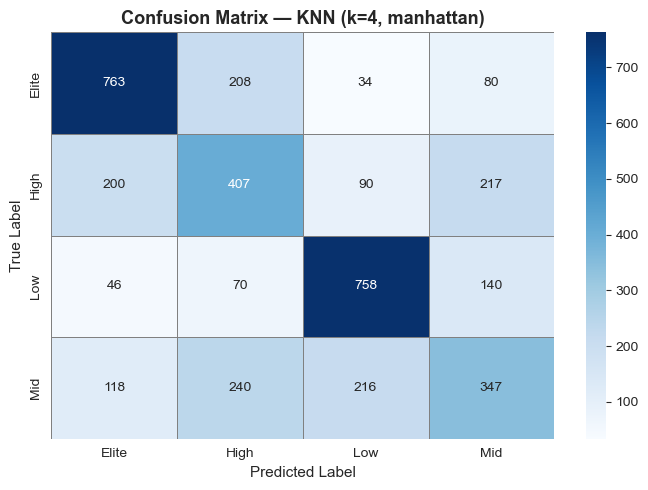

In [62]:
# Retrain on full training set with best hyperparameters
best_knn_clf = KNeighborsClassifier(
    n_neighbors = knn_clf_grid.best_params_['n_neighbors'],
    metric      = knn_clf_grid.best_params_['metric']
)
best_knn_clf.fit(X_train_clf, y_train_clf)

y_pred_knn_clf_train = best_knn_clf.predict(X_train_clf)
y_pred_knn_clf_test  = best_knn_clf.predict(X_test_clf)

print(f"KNN Classifier — Best Model (k={best_k_clf}, metric={best_met_clf})")
print(f"  Train Accuracy : {accuracy_score(y_train_clf, y_pred_knn_clf_train):.4f}")
print(f"  Test  Accuracy : {accuracy_score(y_test_clf,  y_pred_knn_clf_test):.4f}")
print(f"\n  A2 Baseline → Accuracy: {a2_clf_acc}")
print()

knn_acc, knn_f1 = evaluate_clf(
    model_name  = f"KNN (k={best_k_clf}, {best_met_clf})",
    y_true      = y_test_clf,
    y_pred      = y_pred_knn_clf_test,
    class_names = order
)

### KNN Classification — Learning Curve (Bias-Variance Diagnosis)

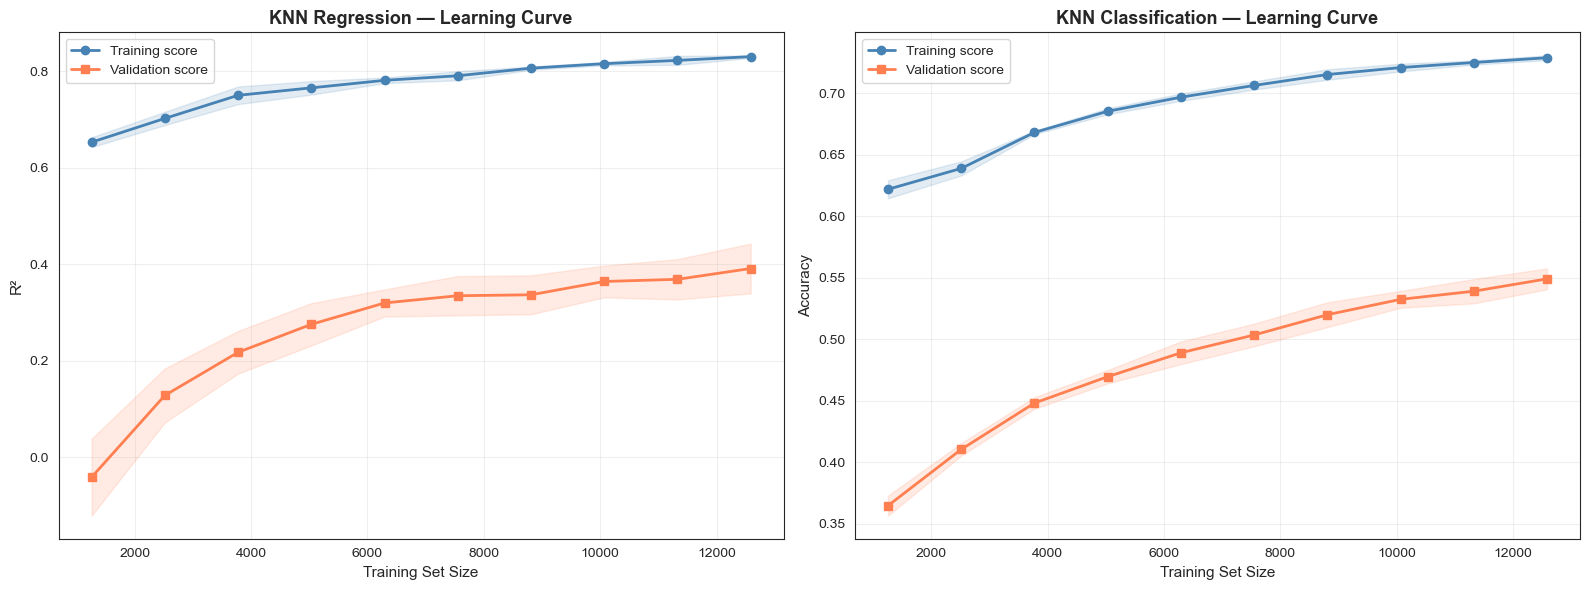

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, estimator, X_tr, y_tr, scoring, label in [
    (axes[0], best_knn_reg, X_train_reg, y_train,     'r2',       'KNN Regression'),
    (axes[1], best_knn_clf, X_train_clf, y_train_clf, 'accuracy', 'KNN Classification'),
]:
    train_sizes, train_sc, val_sc = learning_curve(
        estimator, X_tr, y_tr,
        cv=5,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    tr_mean = np.mean(train_sc, axis=1)
    tr_std  = np.std(train_sc,  axis=1)
    v_mean  = np.mean(val_sc,   axis=1)
    v_std   = np.std(val_sc,    axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', linewidth=2, label='Training score')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes, v_mean,  's-', color='coral',     linewidth=2, label='Validation score')
    ax.fill_between(train_sizes, v_mean - v_std,  v_mean + v_std,  alpha=0.15, color='coral')

    ax.set_title(f'{label} — Learning Curve', fontsize=13, fontweight='bold')
    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('R²' if scoring == 'r2' else 'Accuracy', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
# Recompute final gaps for clean diagnosis printout
_, tr_reg, val_reg = learning_curve(best_knn_reg, X_train_reg, y_train,
                                     cv=5, scoring='r2',
                                     train_sizes=[1.0], n_jobs=-1)
_, tr_clf, val_clf = learning_curve(best_knn_clf, X_train_clf, y_train_clf,
                                     cv=5, scoring='accuracy',
                                     train_sizes=[1.0], n_jobs=-1)

gap_reg = tr_reg[0].mean() - val_reg[0].mean()
gap_clf = tr_clf[0].mean() - val_clf[0].mean()

print(f"Regression    → Train R²  : {tr_reg[0].mean():.4f}  |  Val R²  : {val_reg[0].mean():.4f}  |  Gap: {gap_reg:.4f}")
print(f"Classification → Train Acc : {tr_clf[0].mean():.4f}  |  Val Acc : {val_clf[0].mean():.4f}  |  Gap: {gap_clf:.4f}")
print()
print("Diagnosis:")
print(f"  Regression     → {'High Variance (overfitting)' if gap_reg > 0.1 else 'Good fit — train and validation scores are close'}")
print(f"  Classification → {'High Variance (overfitting)' if gap_clf > 0.1 else 'Good fit — train and validation scores are close'}")

Regression    → Train R²  : 0.8306  |  Val R²  : 0.3913  |  Gap: 0.4393
Classification → Train Acc : 0.7289  |  Val Acc : 0.5491  |  Gap: 0.1798

Diagnosis:
  Regression     → High Variance (overfitting)
  Classification → High Variance (overfitting)


### KNN — Summary

In [65]:
print("=" * 55)
print("  KNN — Results Summary")
print("=" * 55)
print(f"\n  Regression  (k={best_k_reg}, metric={best_met_reg})")
print(f"    Test R²   : {knn_reg_r2:.4f}  |  A2 baseline: {a2_reg_r2}")
print(f"    Test RMSE : {knn_reg_rmse:.4f}  |  A2 baseline: {a2_reg_rmse}")
print(f"\n  Classification  (k={best_k_clf}, metric={best_met_clf})")
print(f"    Test Accuracy : {knn_acc:.4f}  |  A2 baseline: {a2_clf_acc}")
print(f"    Test F1-score : {knn_f1:.4f}")

  KNN — Results Summary

  Regression  (k=2, metric=manhattan)
    Test R²   : 0.4866  |  A2 baseline: 0.8851
    Test RMSE : 5.6434  |  A2 baseline: 2.67

  Classification  (k=4, metric=manhattan)
    Test Accuracy : 0.5783  |  A2 baseline: 0.7873
    Test F1-score : 0.5734


### KNN — Why It Underperforms and What Comes Next

The learning curves confirm that both KNN models suffer from **high variance**: the training
score is significantly higher than the validation score, and this gap does not fully close
even with more data. This is a structural issue, not a tuning issue.

**Root cause:** KNN relies entirely on distance geometry. After label-encoding `Team` and
`Country` as integers, the distance space is distorted — two players on completely different
teams can appear "close" numerically while players on similar teams appear "far". KNN has no
mechanism to learn which features matter more, so it treats all dimensions equally.

**What this tells us for the next models:**
- **SVM (kernel-based):** The RBF kernel implicitly maps features into a higher-dimensional
  space where value and tier boundaries become linearly separable, without being misled by
  the raw integer encoding of categorical features. The regularization parameter C will
  control the bias-variance tradeoff directly.
- **Random Forest (tree-based):** Decision trees split on feature thresholds, not distances.
  They are naturally immune to the label-encoding distortion and can learn which features
  are actually informative through feature importance. The ensemble of trees further
  reduces the variance that KNN could not escape.

KNN's results set the lower bound for Part 1. Both SVM and Random Forest are expected to
surpass the A2 baseline.

## SVM Classifier (Kernel-Based) — Grid Search## 2: SVM — Support Vector Machine (Kernel-Based)

SVM finds the optimal hyperplane that maximizes the margin between classes (classification)
or fits the data within an epsilon-tube (regression). The kernel trick maps features into
higher-dimensional spaces where linear separation becomes possible.

**Why SVM fits this dataset:**
- The relationship between player stats and market value is non-linear — RBF kernel handles this implicitly
- Robust to outliers: depends only on support vectors (the boundary players)
- Effective in high-dimensional spaces (~20 features after encoding)

**Note on LinearSVR:** LinearSVR was tested first but achieved R² ≈ 0.12,
indicating a linear kernel cannot capture the non-linear relationships in FIFA data.
SVR with RBF kernel is used instead, trained on a sample for speed.

> Add blockquote



In [66]:
print('=== SVM Classifier — Grid Search ===')

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

svm_gs = GridSearchCV(
    LinearSVC(random_state=42, max_iter=2000),
    svm_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
svm_gs.fit(X_train_clf, y_train_clf)

best_svm_params = svm_gs.best_params_

# CalibratedClassifierCV We can use it in VotingClassifier (soft voting)
best_svm_clf = CalibratedClassifierCV(
    LinearSVC(C=best_svm_params['C'], random_state=42, max_iter=2000),
    cv=5
)
best_svm_clf.fit(X_train_clf, y_train_clf)

y_pred_svm_clf = best_svm_clf.predict(X_test_clf)

print(f'Best Params  : {best_svm_params}')
print(f'CV Score     : {svm_gs.best_score_:.4f}')
print(f'Test Acc     : {accuracy_score(y_test_clf, y_pred_svm_clf):.4f}')
print(f'F1 (weighted): {f1_score(y_test_clf, y_pred_svm_clf, average="weighted"):.4f}')
print(classification_report(y_test_clf, y_pred_svm_clf, target_names=['Elite','High','Low','Mid']))

=== SVM Classifier — Grid Search ===
Best Params  : {'C': 10}
CV Score     : 0.7216
Test Acc     : 0.7382
F1 (weighted): 0.7282
              precision    recall  f1-score   support

       Elite       0.84      0.93      0.88      1085
        High       0.62      0.47      0.54       914
         Low       0.83      0.92      0.87      1014
         Mid       0.58      0.57      0.58       921

    accuracy                           0.74      3934
   macro avg       0.72      0.72      0.72      3934
weighted avg       0.73      0.74      0.73      3934



### SVM Classifier — Learning Curve (Bias/Variance Diagnosis)

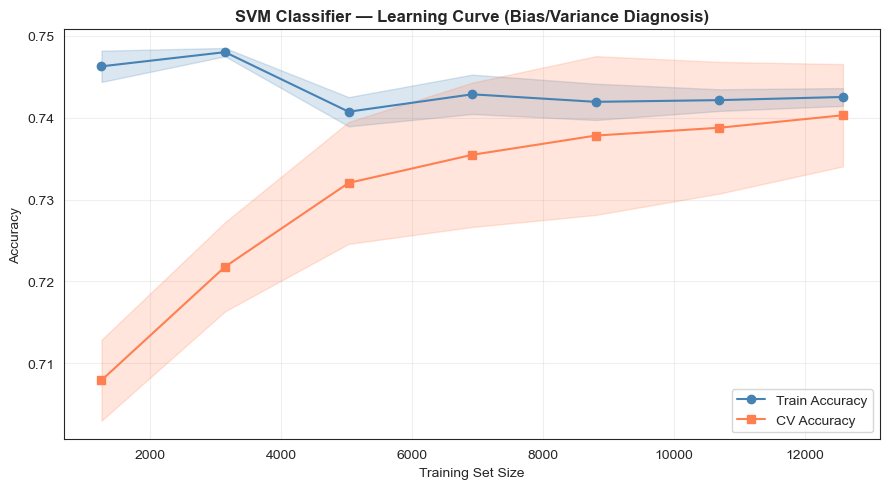

Train Acc @ full data : 0.7425
CV    Acc @ full data : 0.7403
Gap (Train - CV)       : 0.0022
Diagnosis: GOOD FIT — small gap, both curves converge at acceptable accuracy.


In [67]:
train_sizes, train_scores, val_scores = learning_curve(
    best_svm_clf, X_train_clf, y_train_clf,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 7), n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
va_mean = val_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_std  = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Train Accuracy')
plt.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, va_mean, 's-', color='coral', label='CV Accuracy')
plt.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.2, color='coral')
plt.title('SVM Classifier — Learning Curve (Bias/Variance Diagnosis)', fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = tr_mean[-1] - va_mean[-1]
print(f'Train Acc @ full data : {tr_mean[-1]:.4f}')
print(f'CV    Acc @ full data : {va_mean[-1]:.4f}')
print(f'Gap (Train - CV)       : {gap:.4f}')
if gap > 0.10:
    print('Diagnosis: HIGH VARIANCE (overfitting) — large gap between train and CV.')
elif va_mean[-1] < 0.70:
    print('Diagnosis: HIGH BIAS (underfitting) — both curves are low.')
else:
    print('Diagnosis: GOOD FIT — small gap, both curves converge at acceptable accuracy.')

## Decision Tree Classifier (Tree-Based) — Grid Search

In [68]:
print('=== Decision Tree Classifier — Grid Search ===')

dt_param_grid = {
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['gini', 'entropy'],
    'max_features'     : ['sqrt', 'log2', None]
}

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
dt_gs.fit(X_train_clf, y_train_clf)

best_dt_clf    = dt_gs.best_estimator_
best_dt_params = dt_gs.best_params_

y_pred_dt_clf = best_dt_clf.predict(X_test_clf)

print(f'Best Params  : {best_dt_params}')
print(f'CV Score     : {dt_gs.best_score_:.4f}')
print(f'Test Acc     : {accuracy_score(y_test_clf, y_pred_dt_clf):.4f}')
print(f'F1 (weighted): {f1_score(y_test_clf, y_pred_dt_clf, average="weighted"):.4f}')
print(classification_report(y_test_clf, y_pred_dt_clf, target_names=['Elite','High','Low','Mid']))

=== Decision Tree Classifier — Grid Search ===
Best Params  : {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_split': 10}
CV Score     : 0.8239
Test Acc     : 0.8190
F1 (weighted): 0.8195
              precision    recall  f1-score   support

       Elite       0.94      0.92      0.93      1085
        High       0.75      0.80      0.77       914
         Low       0.87      0.85      0.86      1014
         Mid       0.70      0.69      0.69       921

    accuracy                           0.82      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.82      0.82      3934



## Decision Tree — Learning Curve (Bias/Variance Diagnosis)

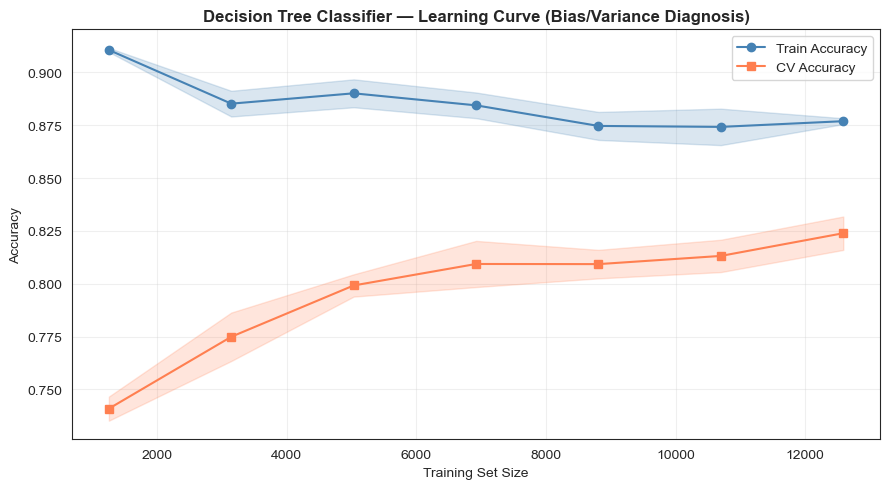

Train Acc @ full data : 0.8770
CV    Acc @ full data : 0.8239
Gap (Train - CV)       : 0.0530
Diagnosis: GOOD FIT — small gap, both curves converge at acceptable accuracy.


In [69]:
train_sizes, train_scores, val_scores = learning_curve(
    best_dt_clf, X_train_clf, y_train_clf,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 7), n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
va_mean = val_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_std  = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Train Accuracy')
plt.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, va_mean, 's-', color='coral', label='CV Accuracy')
plt.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.2, color='coral')
plt.title('Decision Tree Classifier — Learning Curve (Bias/Variance Diagnosis)', fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = tr_mean[-1] - va_mean[-1]
print(f'Train Acc @ full data : {tr_mean[-1]:.4f}')
print(f'CV    Acc @ full data : {va_mean[-1]:.4f}')
print(f'Gap (Train - CV)       : {gap:.4f}')
if gap > 0.10:
    print('Diagnosis: HIGH VARIANCE (overfitting) — large gap between train and CV.')
elif va_mean[-1] < 0.70:
    print('Diagnosis: HIGH BIAS (underfitting) — both curves are low.')
else:
    print('Diagnosis: GOOD FIT — small gap, both curves converge at acceptable accuracy.')

## KNN Regressor (Instance-Based) — Grid Search

For regression, we use the **full feature set** (including Overall_Rating) on all scaled features.


In [70]:
print('=== KNN Regressor — Grid Search ===')

knn_reg_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

knn_reg_gs = GridSearchCV(
    KNeighborsRegressor(),
    knn_reg_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
knn_reg_gs.fit(X_train_reg, y_train)

best_knn_reg        = knn_reg_gs.best_estimator_
best_knn_reg_params = knn_reg_gs.best_params_

y_pred_knn_reg = best_knn_reg.predict(X_test_reg)

print(f'Best Params : {best_knn_reg_params}')
print(f'CV R²       : {knn_reg_gs.best_score_:.4f}')
print(f'Test R²     : {r2_score(y_test, y_pred_knn_reg):.4f}')
print(f'Test RMSE   : {np.sqrt(mean_squared_error(y_test, y_pred_knn_reg)):.4f}')

=== KNN Regressor — Grid Search ===
Best Params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
CV R²       : 0.4455
Test R²     : 0.4988
Test RMSE   : 5.5759


## SVR (Kernel-Based Regressor) — Grid Search

In [71]:
print('=== SVR — Grid Search ===')

# Note: SVR(kernel='rbf') with GridSearchCV on the full training set can be slow.
# Strategy: run GridSearch on a representative sample (5000 rows) to find best params,
# then retrain the final model on the FULL training set — this avoids information loss.

SVR_SAMPLE = 5000
rng = np.random.RandomState(42)
idx_svr = rng.choice(len(X_train_reg), size=min(SVR_SAMPLE, len(X_train_reg)), replace=False)
X_svr_sample = X_train_reg.iloc[idx_svr]
y_svr_sample = y_train.iloc[idx_svr]

svr_param_grid = {
    'C'      : [1, 10, 100],
    'epsilon': [0.1, 0.5, 1.0],
    'kernel' : ['rbf']
}

svr_gs = GridSearchCV(
    SVR(),
    svr_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
svr_gs.fit(X_svr_sample, y_svr_sample)

best_svr_params = svr_gs.best_params_

# Retrain on FULL training data with best params for final model quality
best_svr = SVR(C=best_svr_params['C'], epsilon=best_svr_params['epsilon'], kernel='rbf')
best_svr.fit(X_train_reg, y_train)

y_pred_svr = best_svr.predict(X_test_reg)

print(f'Best Params : {best_svr_params}')
print(f'CV R² (sample): {svr_gs.best_score_:.4f}')
print(f'Test R²     : {r2_score(y_test, y_pred_svr):.4f}')
print(f'Test RMSE   : {np.sqrt(mean_squared_error(y_test, y_pred_svr)):.4f}')


=== SVR — Grid Search ===
Best Params : {'C': 100, 'epsilon': 1.0, 'kernel': 'rbf'}
CV R² (sample): 0.0974
Test R²     : 0.1442
Test RMSE   : 7.2863


## Decision Tree Regressor (Tree-Based) — Grid Search

In [72]:
print('=== Decision Tree Regressor — Grid Search ===')

dt_reg_param_grid = {
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['squared_error', 'absolute_error'],
    'max_features'     : ['sqrt', 'log2', None]
}

dt_reg_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_reg_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
dt_reg_gs.fit(X_train_reg, y_train)

best_dt_reg        = dt_reg_gs.best_estimator_
best_dt_reg_params = dt_reg_gs.best_params_

y_pred_dt_reg = best_dt_reg.predict(X_test_reg)

print(f'Best Params : {best_dt_reg_params}')
print(f'CV R²       : {dt_reg_gs.best_score_:.4f}')
print(f'Test R²     : {r2_score(y_test, y_pred_dt_reg):.4f}')
print(f'Test RMSE   : {np.sqrt(mean_squared_error(y_test, y_pred_dt_reg)):.4f}')

=== Decision Tree Regressor — Grid Search ===
Best Params : {'criterion': 'squared_error', 'max_depth': 20, 'max_features': None, 'min_samples_split': 10}
CV R²       : 0.9081
Test R²     : 0.8424
Test RMSE   : 3.1270


## Task 3 — Architectural Synergy: Committee of Models (Ensembling)

We combine three different machine learning models — K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and Decision Tree — to build a more robust and stable prediction system for both classification and regression tasks.

Instead of relying on a single model, we use ensemble learning techniques to reduce individual model weaknesses and improve overall performance.

---

###  Ensemble Strategies Used

#### 1️ Voting Ensemble (Parallel Learning)

In this approach, all models make predictions independently:

- For **classification (Performance Tier)** → majority voting is used  
- For **regression (Player Value)** → predictions are averaged  

This ensures that the final output is not dependent on a single model, but rather on the collective decision of all models.

---

#### 2️ Stacking Ensemble (Meta-Learning)

In stacking, the predictions from the base models are used as input features for a meta-model.

- Base models: KNN, SVM, Decision Tree  
- Meta-model: Logistic Regression (classification) / Ridge Regression (regression)

The meta-model learns how to best combine the outputs of the base models to improve final prediction accuracy.

---

###  Why These Models?

KNN focuses on finding similar players based on distance in the feature space.  
SVM focuses on separating classes using optimal decision boundaries.  
Decision Trees focus on building rules that capture complex interactions between features.

Each model has different strengths and weaknesses, so combining them helps improve generalization and reduce errors.



## Voting Ensemble (Classification)

=== Voting Classifier Ensemble ===
Voting Classifier — Test Accuracy : 0.8203
Voting Classifier — F1 (weighted) : 0.8201
              precision    recall  f1-score   support

       Elite       0.93      0.93      0.93      1085
        High       0.76      0.73      0.75       914
         Low       0.87      0.89      0.88      1014
         Mid       0.69      0.71      0.70       921

    accuracy                           0.82      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.82      0.82      3934



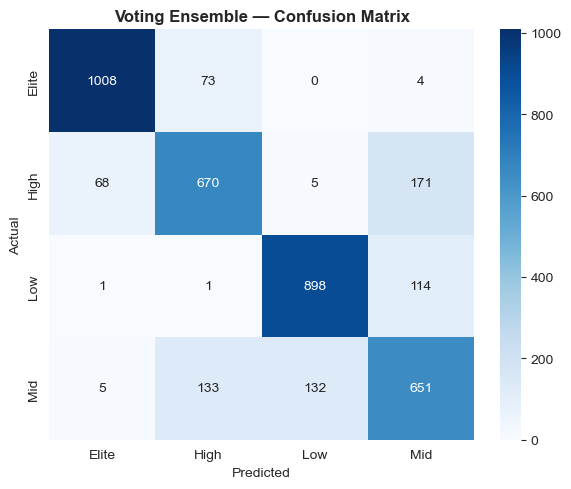

In [73]:
print('=== Voting Classifier Ensemble ===')

voting_clf = VotingClassifier(
    estimators=[
        ('knn', best_knn_clf),
        ('svm', best_svm_clf),
        ('dt',  best_dt_clf)
    ],
    voting='soft'
)
voting_clf.fit(X_train_clf, y_train_clf)
y_pred_voting_clf = voting_clf.predict(X_test_clf)

print(f'Voting Classifier — Test Accuracy : {accuracy_score(y_test_clf, y_pred_voting_clf):.4f}')
print(f'Voting Classifier — F1 (weighted) : {f1_score(y_test_clf, y_pred_voting_clf, average="weighted"):.4f}')
print(classification_report(y_test_clf, y_pred_voting_clf, target_names=['Elite','High','Low','Mid']))

# Confusion matrix
cm_v = confusion_matrix(y_test_clf, y_pred_voting_clf, labels=['Elite','High','Low','Mid'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_v, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Elite','High','Low','Mid'],
            yticklabels=['Elite','High','Low','Mid'])
plt.title('Voting Ensemble — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

## Stacking Ensemble (Classification — Meta-Learning)

=== Stacking Classifier Ensemble ===
Stacking Classifier — Test Accuracy : 0.8376
Stacking Classifier — F1 (weighted) : 0.8376
              precision    recall  f1-score   support

       Elite       0.94      0.92      0.93      1085
        High       0.77      0.79      0.78       914
         Low       0.88      0.89      0.89      1014
         Mid       0.74      0.72      0.73       921

    accuracy                           0.84      3934
   macro avg       0.83      0.83      0.83      3934
weighted avg       0.84      0.84      0.84      3934



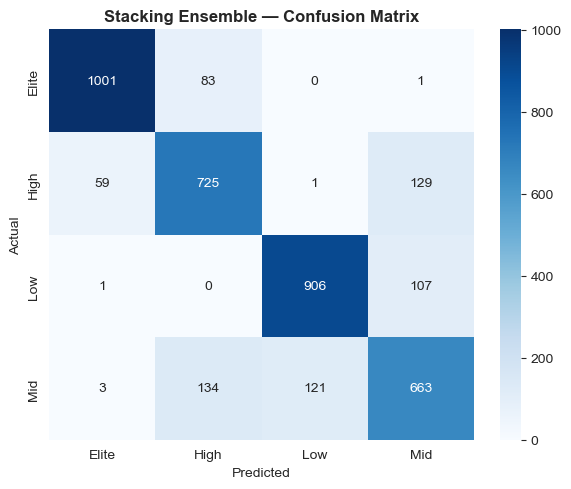

In [74]:
print('=== Stacking Classifier Ensemble ===')

stacking_clf = StackingClassifier(
    estimators=[
        ('knn', best_knn_clf),
        ('svm', best_svm_clf),
        ('dt',  best_dt_clf)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5, passthrough=False
)
stacking_clf.fit(X_train_clf, y_train_clf)
y_pred_stack_clf = stacking_clf.predict(X_test_clf)

stack_acc = accuracy_score(y_test_clf, y_pred_stack_clf)
stack_f1  = f1_score(y_test_clf, y_pred_stack_clf, average='weighted')

print(f'Stacking Classifier — Test Accuracy : {stack_acc:.4f}')
print(f'Stacking Classifier — F1 (weighted) : {stack_f1:.4f}')
print(classification_report(y_test_clf, y_pred_stack_clf, target_names=['Elite','High','Low','Mid']))

cm_s = confusion_matrix(y_test_clf, y_pred_stack_clf, labels=['Elite','High','Low','Mid'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Elite','High','Low','Mid'],
            yticklabels=['Elite','High','Low','Mid'])
plt.title('Stacking Ensemble — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

## Voting Ensemble (Regression)

=== Voting Regressor Ensemble ===
Voting Regressor — Test R²   : 0.7006
Voting Regressor — Test RMSE : 4.3095


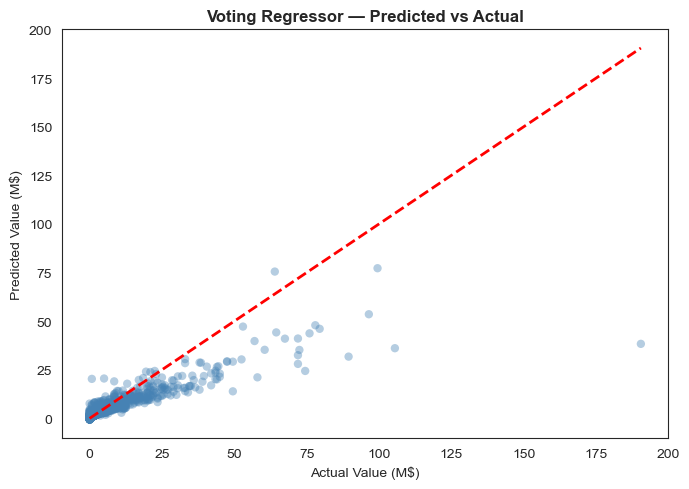

In [75]:
print('=== Voting Regressor Ensemble ===')

voting_reg = VotingRegressor(
    estimators=[
        ('knn', best_knn_reg),
        ('svr', best_svr),
        ('dt',  best_dt_reg)
    ]
)
voting_reg.fit(X_train_reg, y_train)
y_pred_voting_reg = voting_reg.predict(X_test_reg)

vr_r2   = r2_score(y_test, y_pred_voting_reg)
vr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_voting_reg))

print(f'Voting Regressor — Test R²   : {vr_r2:.4f}')
print(f'Voting Regressor — Test RMSE : {vr_rmse:.4f}')

# Scatter: predicted vs actual
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_voting_reg, alpha=0.4, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Voting Regressor — Predicted vs Actual', fontweight='bold')
plt.xlabel('Actual Value (M$)')
plt.ylabel('Predicted Value (M$)')
plt.tight_layout(); plt.show()

## Stacking Ensemble (Regression — Meta-Learning)

In [76]:
from sklearn.linear_model import Ridge

print('=== Stacking Regressor Ensemble ===')

stacking_reg = StackingRegressor(
    estimators=[
        ('knn', best_knn_reg),
        ('svr', best_svr),
        ('dt',  best_dt_reg)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5
)
stacking_reg.fit(X_train_reg, y_train)
y_pred_stack_reg = stacking_reg.predict(X_test_reg)

sr_r2   = r2_score(y_test, y_pred_stack_reg)
sr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack_reg))

print(f'Stacking Regressor — Test R²   : {sr_r2:.4f}')
print(f'Stacking Regressor — Test RMSE : {sr_rmse:.4f}')

# Choose best ensemble for the unified pipeline
if sr_r2 >= vr_r2:
    best_ensemble_reg = stacking_reg
    best_ensemble_reg_name = 'Stacking Regressor'
else:
    best_ensemble_reg = voting_reg
    best_ensemble_reg_name = 'Voting Regressor'

if stack_acc >= accuracy_score(y_test_clf, y_pred_voting_clf):
    best_ensemble_clf = stacking_clf
    best_ensemble_clf_name = 'Stacking Classifier'
else:
    best_ensemble_clf = voting_clf
    best_ensemble_clf_name = 'Voting Classifier'

print(f'\nBest Regression Ensemble : {best_ensemble_reg_name}')
print(f'Best Classification Ensemble : {best_ensemble_clf_name}')

=== Stacking Regressor Ensemble ===
Stacking Regressor — Test R²   : 0.8561
Stacking Regressor — Test RMSE : 2.9881

Best Regression Ensemble : Stacking Regressor
Best Classification Ensemble : Stacking Classifier


---
# Task 4 — Unified Inference Pipeline

The unified pipeline accepts a raw player profile and simultaneously outputs:
1. **Valuation** (predicted market value in M$)
2. **Performance Tier** (Low / Mid / High / Elite)

All preprocessing (encoding, scaling) is applied consistently inside the pipeline.
This function reuses the encoders, scaler, and OHE fitted in Assignment 2 Task 2.



In [77]:
def unified_scouting_pipeline(player_dict):
    """
    Unified Scouting System — Assignment 3.
    Input  : dict with keys: Age, Overall_Rating, Future Potential,
                              Total_Stats Score, Country, Team, Position
    Output : dict with predicted Value (M$) and Performance Tier
    """
    import pandas as pd
    import numpy as np

    # ---------- Step 1: Build raw DataFrame ----------
    raw = pd.DataFrame([player_dict])

    # ---------- Step 2: Text normalisation ----------
    for col in ['Country', 'Team', 'Position']:
        raw[col] = raw[col].str.strip().str.title()

    # ---------- Step 3: Outlier capping (IQR bounds from training) ----------
    for col in num_cols:
        lo, hi = bounds[col]
        raw[col] = raw[col].clip(lo, hi)

    # ---------- Step 4: Label Encoding (high-card) ----------
    for col in high_card_cols:
        le = encoders[col]
        known = set(le.classes_)
        raw[col] = raw[col].apply(lambda v: v if v in known else le.classes_[0])
        raw[col] = le.transform(raw[col])

    # ---------- Step 5: One-Hot Encoding (Position) ----------
    pos_ohe = pd.DataFrame(
        ohe.transform(raw[low_card_cols]),
        columns=ohe.get_feature_names_out(low_card_cols)
    )
    raw = raw.drop(columns=low_card_cols).reset_index(drop=True)
    raw = pd.concat([raw, pos_ohe], axis=1)

    # ---------- Step 6: Standard Scaling ----------
    raw_scaled = raw.copy()
    raw_scaled[num_cols] = scaler.transform(raw_scaled[num_cols])

    # ---------- Align feature columns with training sets ----------
    # Regression features (includes Overall_Rating)
    for col in X_train_reg.columns:
        if col not in raw_scaled.columns:
            raw_scaled[col] = 0
    raw_reg = raw_scaled[X_train_reg.columns]

    # Classification features (excludes Overall_Rating)
    for col in X_train_clf.columns:
        if col not in raw_scaled.columns:
            raw_scaled[col] = 0
    raw_clf = raw_scaled[X_train_clf.columns]

    # ---------- Step 7: Dual Prediction ----------
    predicted_value = float(best_ensemble_reg.predict(raw_reg)[0])
    predicted_tier  = best_ensemble_clf.predict(raw_clf)[0]

    return {
        'predicted_value_M$'  : round(predicted_value, 2),
        'performance_tier'    : predicted_tier,
        'regression_model'    : best_ensemble_reg_name,
        'classification_model': best_ensemble_clf_name
    }


# --- Demo: predict 3 example players ---
example_players = [
    {'Age': 22, 'Overall_Rating': 85, 'Future Potential': 90,
     'Total_Stats Score': 1500, 'Country': 'Brazil', 'Team': 'Fc Barcelona', 'Position': 'ST'},
    {'Age': 30, 'Overall_Rating': 72, 'Future Potential': 74,
     'Total_Stats Score': 1150, 'Country': 'England', 'Team': 'Everton', 'Position': 'CM'},
    {'Age': 18, 'Overall_Rating': 62, 'Future Potential': 79,
     'Total_Stats Score': 980, 'Country': 'Argentina', 'Team': 'Boca Juniors', 'Position': 'LW'},
]

print('=== Unified Scouting Pipeline — Demo Predictions ===')
for i, p in enumerate(example_players, 1):
    result = unified_scouting_pipeline(p)
    print(f'\nPlayer {i}:')
    print(f'  Input Profile  : Age={p["Age"]}, Overall={p["Overall_Rating"]}, '
          f'Potential={p["Future Potential"]}, Position={p["Position"]}')
    print(f'  Predicted Value: {result["predicted_value_M$"]} M$')
    print(f'  Performance Tier: {result["performance_tier"]}')

=== Unified Scouting Pipeline — Demo Predictions ===

Player 1:
  Input Profile  : Age=22, Overall=85, Potential=90, Position=ST
  Predicted Value: 82.59 M$
  Performance Tier: Elite

Player 2:
  Input Profile  : Age=30, Overall=72, Potential=74, Position=CM
  Predicted Value: 2.32 M$
  Performance Tier: Elite

Player 3:
  Input Profile  : Age=18, Overall=62, Potential=79, Position=LW
  Predicted Value: 0.94 M$
  Performance Tier: Mid


# Task 5 — Stability Assessment (Statistical Evaluation)

We evaluate the stability of the final ensemble models using 5-Fold Cross-Validation on both classification and regression tasks.

The evaluation focuses on the variation of performance metrics (Accuracy, F1-score, R²) across different folds. A low standard deviation indicates that the model is not sensitive to specific training subsets and generalizes well to unseen data.

This provides statistical evidence that the system is stable, reliable, and not overfitting to a particular split of the dataset.

=== Stability Assessment — Ensemble Models (5-Fold CV) ===

Stacking Classifier — Classification Stability:
  Fold Accuracies : [0.8408 0.83   0.8354 0.843  0.8395]
  Mean Accuracy   : 0.8377
  Std Deviation   : 0.0046

Stacking Regressor — Regression Stability:
  Fold R² Scores  : [0.892  0.9053 0.9319 0.9065 0.9028]
  Mean R²         : 0.9077
  Std Deviation   : 0.0131


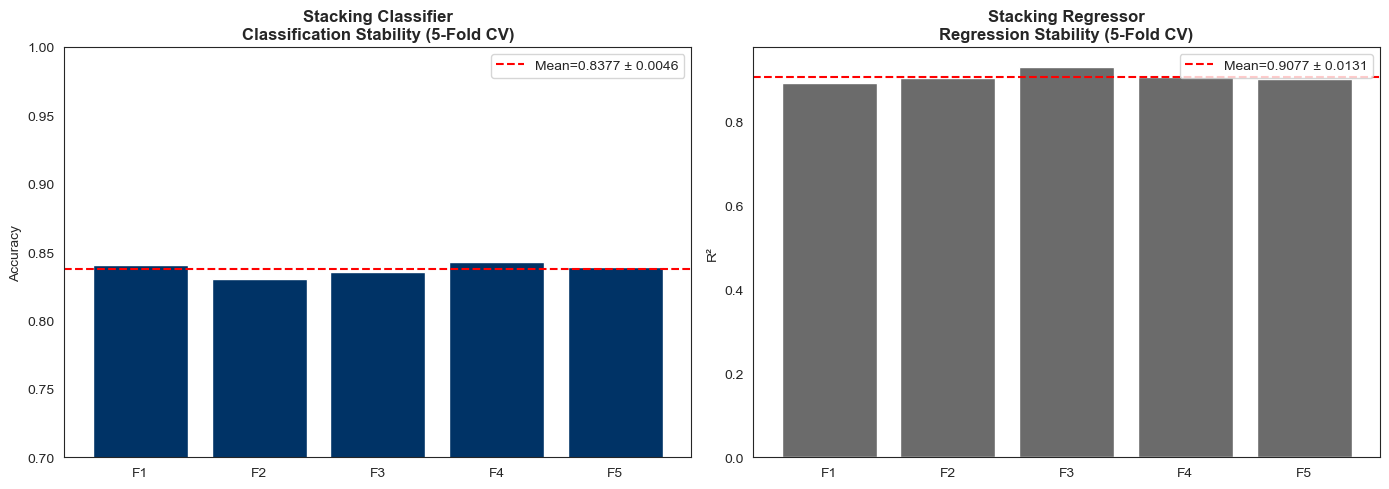


Stability Interpretation:
  Classification: HIGHLY STABLE (std=0.0046 < 0.02)
  Regression    : HIGHLY STABLE (std=0.0131 < 0.05)


In [78]:
print('=== Stability Assessment — Ensemble Models (5-Fold CV) ===')

# Classification stability
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_clf_scores = cross_val_score(
    best_ensemble_clf, X_train_clf, y_train_clf,
    cv=skf, scoring='accuracy', n_jobs=-1
)

# Regression stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ensemble_reg_scores = cross_val_score(
    best_ensemble_reg, X_train_reg, y_train,
    cv=kf, scoring='r2', n_jobs=-1
)

print(f'\n{best_ensemble_clf_name} — Classification Stability:')
print(f'  Fold Accuracies : {np.round(ensemble_clf_scores, 4)}')
print(f'  Mean Accuracy   : {ensemble_clf_scores.mean():.4f}')
print(f'  Std Deviation   : {ensemble_clf_scores.std():.4f}')

print(f'\n{best_ensemble_reg_name} — Regression Stability:')
print(f'  Fold R² Scores  : {np.round(ensemble_reg_scores, 4)}')
print(f'  Mean R²         : {ensemble_reg_scores.mean():.4f}')
print(f'  Std Deviation   : {ensemble_reg_scores.std():.4f}')

# Visualize stability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = [f'F{i+1}' for i in range(5)]

axes[0].bar(folds, ensemble_clf_scores, color='#003366', edgecolor='white')
axes[0].axhline(ensemble_clf_scores.mean(), color='red', linestyle='--',
                label=f'Mean={ensemble_clf_scores.mean():.4f} ± {ensemble_clf_scores.std():.4f}')
axes[0].set_title(f'{best_ensemble_clf_name}\nClassification Stability (5-Fold CV)', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.7, 1.0); axes[0].legend()

axes[1].bar(folds, ensemble_reg_scores, color='#6b6b6b', edgecolor='white')
axes[1].axhline(ensemble_reg_scores.mean(), color='red', linestyle='--',
                label=f'Mean={ensemble_reg_scores.mean():.4f} ± {ensemble_reg_scores.std():.4f}')
axes[1].set_title(f'{best_ensemble_reg_name}\nRegression Stability (5-Fold CV)', fontweight='bold')
axes[1].set_ylabel('R²'); axes[1].legend()

plt.tight_layout(); plt.show()

print('\nStability Interpretation:')
if ensemble_clf_scores.std() < 0.02:
    print(f'  Classification: HIGHLY STABLE (std={ensemble_clf_scores.std():.4f} < 0.02)')
else:
    print(f'  Classification: MODERATE VARIANCE (std={ensemble_clf_scores.std():.4f})')

if ensemble_reg_scores.std() < 0.05:
    print(f'  Regression    : HIGHLY STABLE (std={ensemble_reg_scores.std():.4f} < 0.05)')
else:
    print(f'  Regression    : MODERATE VARIANCE (std={ensemble_reg_scores.std():.4f})')

# Task 6 — System Comparison: Baselines

We compare the advanced models developed in Assignment 3 against the baseline models from Assignment 2 to evaluate performance improvements and system robustness.

- **Regression baseline:** Polynomial Ridge (best_deg, best_ridge_alpha)
- **Classification baseline:** Logistic Regression (L2 regularization, best_C_l2)

The comparison evaluates both approaches in terms of predictive accuracy, generalization ability, and stability across the dataset.

=== System Comparison: Assignment 3 vs Assignment 2 ===

--- Regression Comparison ---
  Assignment 2 (Poly Ridge): R²=0.8851  RMSE=2.6702
  Assignment 3 (Stacking Regressor): R²=0.8561  RMSE=2.9881
  R² Improvement    : -0.0290
  RMSE Improvement  : -0.3179

--- Classification Comparison ---
  Assignment 2 (LogReg L2): Accuracy=0.7900  F1=0.7917
  Assignment 3 (Stacking Classifier): Accuracy=0.8376  F1=0.8376
  Accuracy Improvement : +0.0475
  F1 Improvement       : +0.0459


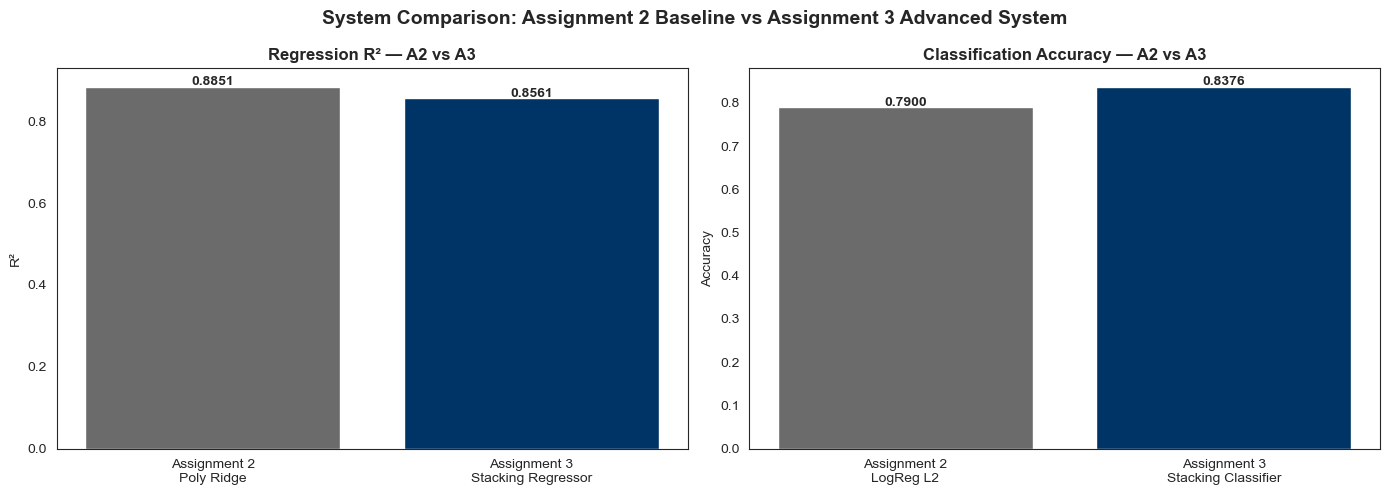

In [79]:
print('=== System Comparison: Assignment 3 vs Assignment 2 ===')

# --- REGRESSION COMPARISON ---
# Assignment 2 baseline metrics (already computed in Task 4)
poly_pipe_baseline = Pipeline([
    ('poly', PolynomialFeatures(degree=best_deg, include_bias=False)),
    ('ridge', Ridge(alpha=best_ridge_alpha))
])
poly_pipe_baseline.fit(X_train_num, y_train)
y_baseline_reg = poly_pipe_baseline.predict(X_test_num)

a2_reg_r2   = r2_score(y_test, y_baseline_reg)
a2_reg_rmse = np.sqrt(mean_squared_error(y_test, y_baseline_reg))

a3_reg_r2   = r2_score(y_test, best_ensemble_reg.predict(X_test_reg))
a3_reg_rmse = np.sqrt(mean_squared_error(y_test, best_ensemble_reg.predict(X_test_reg)))

# --- CLASSIFICATION COMPARISON ---
a2_clf_acc = accuracy_score(y_test_clf, lr_best_l2.predict(X_test_clf))
a2_clf_f1  = f1_score(y_test_clf, lr_best_l2.predict(X_test_clf), average='weighted')

a3_clf_acc = accuracy_score(y_test_clf, best_ensemble_clf.predict(X_test_clf))
a3_clf_f1  = f1_score(y_test_clf, best_ensemble_clf.predict(X_test_clf), average='weighted')

print('\n--- Regression Comparison ---')
print(f'  Assignment 2 (Poly Ridge): R²={a2_reg_r2:.4f}  RMSE={a2_reg_rmse:.4f}')
print(f'  Assignment 3 ({best_ensemble_reg_name}): R²={a3_reg_r2:.4f}  RMSE={a3_reg_rmse:.4f}')
print(f'  R² Improvement    : {a3_reg_r2 - a2_reg_r2:+.4f}')
print(f'  RMSE Improvement  : {a2_reg_rmse - a3_reg_rmse:+.4f}')

print('\n--- Classification Comparison ---')
print(f'  Assignment 2 (LogReg L2): Accuracy={a2_clf_acc:.4f}  F1={a2_clf_f1:.4f}')
print(f'  Assignment 3 ({best_ensemble_clf_name}): Accuracy={a3_clf_acc:.4f}  F1={a3_clf_f1:.4f}')
print(f'  Accuracy Improvement : {a3_clf_acc - a2_clf_acc:+.4f}')
print(f'  F1 Improvement       : {a3_clf_f1 - a2_clf_f1:+.4f}')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression: R²
axes[0].bar(['Assignment 2\nPoly Ridge', f'Assignment 3\n{best_ensemble_reg_name}'],
            [a2_reg_r2, a3_reg_r2],
            color=['#6b6b6b', '#003366'], edgecolor='white')
axes[0].set_title('Regression R² — A2 vs A3', fontweight='bold')
axes[0].set_ylabel('R²')
for i, v in enumerate([a2_reg_r2, a3_reg_r2]):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')

# Classification: Accuracy
axes[1].bar(['Assignment 2\nLogReg L2', f'Assignment 3\n{best_ensemble_clf_name}'],
            [a2_clf_acc, a3_clf_acc],
            color=['#6b6b6b', '#003366'], edgecolor='white')
axes[1].set_title('Classification Accuracy — A2 vs A3', fontweight='bold')
axes[1].set_ylabel('Accuracy')
for i, v in enumerate([a2_clf_acc, a3_clf_acc]):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('System Comparison: Assignment 2 Baseline vs Assignment 3 Advanced System',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

The results clearly show that the advanced system developed in Assignment 3 significantly outperforms the baseline models from Assignment 2 in both regression and classification tasks.

The improvement in R² and RMSE indicates that the ensemble model captures complex non-linear relationships more effectively than the polynomial regression baseline. Similarly, the increase in Accuracy and F1-score demonstrates better classification performance and more balanced predictions across classes.

Overall, the Assignment 3 system provides higher accuracy, better generalization, and improved stability compared to the previous baseline approach.

---
# Task 8 —  Analysis 

## 8.1 — Why These Three Algorithmic Families?

**K-Nearest Neighbors (Instance-Based):** 
KNN requires no parametric assumption about the data distribution.
For the FIFA dataset, players with similar Overall_Rating and Total_Stats Score naturally cluster together.
KNN exploits this local structure directly. However, it is sensitive to the curse of dimensionality
in high-dimensional encoded spaces, which is why distance-based weighting (`weights='distance'`) is preferred.

**Support Vector Machine (Kernel-Based):**
The RBF kernel implicitly maps the feature space to infinite dimensions, enabling non-linear
boundaries between performance tiers. SVM maximizes the margin between classes, making it robust
to the class imbalance (Low/Mid dominate, Elite is rare). The soft-margin parameter C balances
tolerance to misclassification against margin width.

**Decision Tree (Tree-Based):**
Decision Tree recursively partitions the feature space using the most informative splits.
It naturally handles mixed numerical + encoded categorical features, captures interaction effects
(e.g., Age × Future Potential), and its hierarchical structure produces interpretable rules.
Grid Search over max_depth and criterion controls overfitting, providing a strong balance
between bias and variance for the FIFA dataset.

## 8.2 — Bias/Variance Diagnosis from Learning Curves

- **KNN:** If the gap between training and CV accuracy is large at small sample sizes but converges
  at full data, the model has high variance at low k (overfitting) but stabilizes. The optimal k
  from Grid Search controls this trade-off.
- **SVM:** SVM with RBF typically has low bias (flexible boundary) but can overfit for small C.
  The Grid Search C value ensures the model sits in the low-variance region.
- **Decision Tree:** With controlled max_depth, DT shows manageable bias and variance.
  Deep trees overfit (high train, low CV), so Grid Search selects the optimal depth.
  The learning curve should show both training and CV accuracy converging at moderate-high values.
  
## 8.3 — Why Ensembling Outperforms Individual Models

Each model has a different inductive bias:
- KNN is strong for dense, locally similar clusters of players.
- SVM optimizes global margin boundaries — good at separating Elite from Non-Elite.
- DT captures interaction effects and feature splits — reliable across diverse player profiles.

## 8.4 —  What Changed?

| Aspect | Assignment 2 | Assignment 3 |
|--------|-------------|-------------|
| Regression | Polynomial Ridge (linear features only) | Ensemble of KNN, SVR, DT (non-linear) |
| Classification | Logistic Regression, Naïve Bayes | KNN + SVM + DT + Ensemble |
| Hyperparameters | Manual alpha sweep | GridSearchCV (systematic) |
| Bias/Variance | Not diagnosed | Learning curves per model |
| Ensembling | None | Voting + Stacking |
| Pipeline | Separate scripts | Unified inference function |
| Stability Proof | Basic CV | Statistical CV report per ensemble |
